In [1]:
import os
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import json

In [2]:
IMG_HEIGHT    = 112
IMG_WIDTH     = 112
NUM_CLASSES   = 40
BATCH_SIZE    = 16
EPOCHS        = 50
LEARNING_RATE = 1e-2
WEIGHT_DECAY  = 5e-4
MOMENTUM      = 0.9
DEVICE        = "cpu"

In [3]:
# Rutas
DATASET_PATH        = "../../dataset/"   
TRAIN_PATH          = "../../../dataset/ORL_limpio/Training"
TEST_PATH           = "../../../dataset/ORL_limpio/Testing"
SR_TRAIN_PATH_X4 = "../../../dataset/Tecnica De mejora de imagen/ORL_SuperResolution_x4/Training"         
SR_TEST_PATH_X4  = "../../../dataset/Tecnica De mejora de imagen/ORL_SuperResolution_x4/Testing"

# EXPERIMENTO 1 SIN REENTRENAR EL MODELO APLICACIÓN DE SR X4


In [4]:
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_HEIGHT, IMG_WIDTH)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.1)),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])
 
test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_HEIGHT, IMG_WIDTH)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])
SR_x4_train_dataset = datasets.ImageFolder(SR_TRAIN_PATH_X4, transform=train_transform)
SR_x4_test_dataset  = datasets.ImageFolder(SR_TEST_PATH_X4,  transform=test_transform)
 
SR_x4_train_loader = DataLoader(SR_x4_train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                                    num_workers=0, pin_memory=False)
SR_x4_test_loader  = DataLoader(SR_x4_test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                                    num_workers=0, pin_memory=False)
 
SR_x4_class_names = SR_x4_train_dataset.classes
print(f"[Sr x4] Clases: {len(SR_x4_class_names)}")
print(f"[SR x4] Train: {len(SR_x4_train_dataset)} imágenes | Test: {len(SR_x4_test_dataset)} imágenes")
 

[Sr x4] Clases: 40
[SR x4] Train: 360 imágenes | Test: 40 imágenes


In [5]:
class ConvBNPReLU(nn.Module):
    def __init__(self, in_c, out_c, kernel_size, stride=1, padding=0, groups=1):
        super().__init__()
        self.conv = nn.Conv2d(in_c, out_c, kernel_size, stride=stride,
                               padding=padding, groups=groups, bias=False)
        self.bn   = nn.BatchNorm2d(out_c)
        self.act  = nn.PReLU(out_c)
 
    def forward(self, x):
        return self.act(self.bn(self.conv(x)))
 
 
def _make_divisible(v, divisor=4, min_value=None):
    if min_value is None:
        min_value = divisor
    new_v = max(min_value, int(v + divisor / 2) // divisor * divisor)
    if new_v < 0.9 * v:
        new_v += divisor
    return new_v
 
 
class SqueezeExcite(nn.Module):
    """SE con PReLU en la reduccion."""
    def __init__(self, in_chs, se_ratio=0.25):
        super().__init__()
        reduced_chs = _make_divisible(int(in_chs * se_ratio))
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.conv_reduce = nn.Conv2d(in_chs, reduced_chs, 1, bias=True)
        self.act = nn.PReLU(reduced_chs)
        self.conv_expand = nn.Conv2d(reduced_chs, in_chs, 1, bias=True)
 
    def forward(self, x):
        x_se = self.avg_pool(x)
        x_se = self.act(self.conv_reduce(x_se))
        x_se = self.conv_expand(x_se)
        return x * torch.sigmoid(x_se)
 
 
class DFCAttention(nn.Module):
    def __init__(self, chs, kernel_size=5):
        super().__init__()
        pad = kernel_size // 2
        self.pool = nn.AvgPool2d(kernel_size=2, stride=2)
        self.conv_h = nn.Conv2d(chs, chs, kernel_size=(1, kernel_size),
                                 padding=(0, pad), groups=chs, bias=False)
        self.conv_v = nn.Conv2d(chs, chs, kernel_size=(kernel_size, 1),
                                 padding=(pad, 0), groups=chs, bias=False)
        self.bn = nn.BatchNorm2d(chs)
 
    def forward(self, x):
        h, w = x.shape[-2:]
        att = self.pool(x)
        att = self.conv_h(att)
        att = self.conv_v(att)
        att = self.bn(att)
        att = torch.sigmoid(att)
        att = F.interpolate(att, size=(h, w), mode="nearest")
        return att

In [6]:
class GhostModule(nn.Module):
    def __init__(self, in_chs, out_chs, kernel_size=1, ratio=2, dw_size=3,
                 stride=1, use_act=True):
        super().__init__()
        self.out_chs = out_chs
        init_chs = math.ceil(out_chs / ratio)
        new_chs = init_chs * (ratio - 1)
 
        self.primary_conv = nn.Sequential(
            nn.Conv2d(in_chs, init_chs, kernel_size, stride,
                      kernel_size // 2, bias=False),
            nn.BatchNorm2d(init_chs),
            nn.PReLU(init_chs) if use_act else nn.Identity(),
        )
        self.cheap_operation = nn.Sequential(
            nn.Conv2d(init_chs, new_chs, dw_size, 1, dw_size // 2,
                      groups=init_chs, bias=False),
            nn.BatchNorm2d(new_chs),
            nn.PReLU(new_chs) if use_act else nn.Identity(),
        )
 
    def forward(self, x):
        x1 = self.primary_conv(x)
        x2 = self.cheap_operation(x1)
        out = torch.cat([x1, x2], dim=1)
        return out[:, :self.out_chs, :, :]
 
 
class GhostBottleneckV2(nn.Module):
    def __init__(self, in_chs, mid_chs, out_chs, dw_kernel_size=3,
                 stride=1, se_ratio=0.0, use_dfc=True):
        super().__init__()
        has_se = se_ratio is not None and se_ratio > 0.0
        self.stride = stride
        self.use_dfc = use_dfc

        if use_dfc:
            self.dfc = DFCAttention(mid_chs)          # <-- antes: DFCAttention(in_chs)

        self.ghost1 = GhostModule(in_chs, mid_chs, use_act=True)

        if stride > 1:
            self.conv_dw = nn.Conv2d(mid_chs, mid_chs, dw_kernel_size,
                                      stride=stride,
                                      padding=(dw_kernel_size - 1) // 2,
                                      groups=mid_chs, bias=False)
            self.bn_dw = nn.BatchNorm2d(mid_chs)
        else:
            self.conv_dw = None

        self.se = SqueezeExcite(mid_chs, se_ratio) if has_se else None

        self.ghost2 = GhostModule(mid_chs, out_chs, use_act=False)

        if in_chs == out_chs and stride == 1:
            self.shortcut = nn.Identity()
        else:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_chs, in_chs, dw_kernel_size, stride=stride,
                          padding=(dw_kernel_size - 1) // 2,
                          groups=in_chs, bias=False),
                nn.BatchNorm2d(in_chs),
                nn.Conv2d(in_chs, out_chs, 1, 1, 0, bias=False),
                nn.BatchNorm2d(out_chs),
            )
        self.out_channels = out_chs

    def forward(self, x):
        residual = x
        x1 = self.ghost1(x)

        if self.conv_dw is not None:
            x1 = self.bn_dw(self.conv_dw(x1))

        if self.use_dfc:
            att = self.dfc(x1)                      
            if att.shape[-2:] != x1.shape[-2:]:
                att = F.interpolate(att, size=x1.shape[-2:], mode="nearest")
            x1 = x1 * att

        if self.se is not None:
            x1 = self.se(x1)

        x1 = self.ghost2(x1)
        return x1 + self.shortcut(residual)

In [7]:
class GhostFaceNetV2(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, embedding_dim=128,
                 dropout_p=0.4, use_dfc=True):
        super().__init__()
 
        # Stem: conv 3x3 stride=2 -> 112x112 -> 56x56
        self.stem = ConvBNPReLU(1, 16, 3, stride=2, padding=1)
 
        # Etapa 1: 56x56 -> 28x28
        self.stage1 = nn.Sequential(
            GhostBottleneckV2(16, mid_chs=48, out_chs=24, dw_kernel_size=3,
                               stride=2, se_ratio=0.0, use_dfc=use_dfc)
        )
        c1 = self.stage1[-1].out_channels  # 24
 
        # Etapa 2: 28x28 -> 14x14 (1 stride=2 + 2 stride=1)
        stage2_blocks = [
            GhostBottleneckV2(c1, mid_chs=72, out_chs=40, dw_kernel_size=5,
                               stride=2, se_ratio=0.25, use_dfc=use_dfc)
        ]
        c2 = stage2_blocks[-1].out_channels
        for _ in range(2):
            stage2_blocks.append(
                GhostBottleneckV2(c2, mid_chs=120, out_chs=40, dw_kernel_size=5,
                                   stride=1, se_ratio=0.25, use_dfc=use_dfc)
            )
            c2 = stage2_blocks[-1].out_channels
        self.stage2 = nn.Sequential(*stage2_blocks)
 
        # Etapa 3: 14x14 -> 7x7 (1 stride=2 + 3 stride=1)
        stage3_blocks = [
            GhostBottleneckV2(c2, mid_chs=240, out_chs=80, dw_kernel_size=3,
                               stride=2, se_ratio=0.0, use_dfc=use_dfc)
        ]
        c3 = stage3_blocks[-1].out_channels
        mids3 = [200, 184, 184]
        se3 = [0.0, 0.0, 0.25]
        for mid, se in zip(mids3, se3):
            stage3_blocks.append(
                GhostBottleneckV2(c3, mid_chs=mid, out_chs=80, dw_kernel_size=3,
                                   stride=1, se_ratio=se, use_dfc=use_dfc)
            )
            c3 = stage3_blocks[-1].out_channels
        self.stage3 = nn.Sequential(*stage3_blocks)
 
        # Etapa 4: 7x7 -> 7x7 (2 bloques stride=1)
        stage4_blocks = []
        c4 = c3
        for mid in [480, 672]:
            stage4_blocks.append(
                GhostBottleneckV2(c4, mid_chs=mid, out_chs=112, dw_kernel_size=3,
                                   stride=1, se_ratio=0.25, use_dfc=use_dfc)
            )
            c4 = stage4_blocks[-1].out_channels
        self.stage4 = nn.Sequential(*stage4_blocks)
 
        # Conv 1x1 expansión
        self.conv_expand = ConvBNPReLU(c4, 256, 1)
 
        # GDC: Global Depthwise Conv 7x7 -> reduce a (1,1)
        self.gdc = nn.Sequential(
            nn.Conv2d(256, 256, kernel_size=7, groups=256, bias=False),
            nn.GroupNorm(num_groups=16, num_channels=256)
        )
 
        # Embedding 128-D
        self.embedding = nn.Sequential(
            nn.Conv2d(256, embedding_dim, 1, bias=False),
            nn.GroupNorm(num_groups=8, num_channels=embedding_dim),
            nn.Flatten()
        )
 
        # Dropout antes del classifier (regularización contra overfitting)
        self.dropout = nn.Dropout(p=dropout_p)
 
        self.classifier = nn.Linear(embedding_dim, num_classes)
 
    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = self.conv_expand(x)
        x = self.gdc(x)
        x = self.embedding(x)
        x = self.dropout(x)
        return self.classifier(x)
 
 
model = GhostFaceNetV2(num_classes=NUM_CLASSES, use_dfc=True).to(DEVICE)
print(model)
 
dummy = torch.zeros(1, 1, IMG_HEIGHT, IMG_WIDTH).to(DEVICE)
out   = model(dummy)
print(f"\nShape de salida con input (1,1,112,112): {out.shape}")  

GhostFaceNetV2(
  (stem): ConvBNPReLU(
    (conv): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act): PReLU(num_parameters=16)
  )
  (stage1): Sequential(
    (0): GhostBottleneckV2(
      (dfc): DFCAttention(
        (pool): AvgPool2d(kernel_size=2, stride=2, padding=0)
        (conv_h): Conv2d(48, 48, kernel_size=(1, 5), stride=(1, 1), padding=(0, 2), groups=48, bias=False)
        (conv_v): Conv2d(48, 48, kernel_size=(5, 1), stride=(1, 1), padding=(2, 0), groups=48, bias=False)
        (bn): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (ghost1): GhostModule(
        (primary_conv): Sequential(
          (0): Conv2d(16, 24, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): PReLU(num_parameters=24)
        

In [8]:
model_ref_Gh = GhostFaceNetV2(num_classes=NUM_CLASSES, use_dfc=True).to(DEVICE)
model_ref_Gh.load_state_dict(torch.load("best_ghostfacenet_orl.pth", map_location=DEVICE))
model_ref_Gh.eval()
 
all_preds_Gh, all_labels_Gh, all_confs_Gh = [], [], []
with torch.no_grad():
    for images, labels in SR_x4_test_loader:
        images = images.to(DEVICE)
        outputs = model_ref_Gh(images)
        probs = F.softmax(outputs, dim=1)
        confs, preds = torch.max(probs, dim=1)
        all_preds_Gh.extend(preds.cpu().numpy())
        all_labels_Gh.extend(labels.numpy())
        all_confs_Gh.extend(confs.cpu().numpy())
 
all_preds_Gh  = np.array(all_preds_Gh)
all_labels_Gh = np.array(all_labels_Gh)
all_confs_Gh  = np.array(all_confs_Gh) * 100
 
acc_sin_reentrenar = 100 * np.sum(all_preds_Gh == all_labels_Gh) / len(all_labels_Gh)
print("\n=== [SR x4] Experimento 1 — Sin reentrenar ===")
print(f"Accuracy total      : {acc_sin_reentrenar:.2f}% ({int((all_preds_Gh==all_labels_Gh).sum())}/{len(all_labels_Gh)})")
print(f"Confianza promedio  : {all_confs_Gh.mean():.2f}%")
print(f"Confianza mínima    : {all_confs_Gh.min():.2f}%")
print(f"Confianza máxima    : {all_confs_Gh.max():.2f}%")
print(f"Desviación estándar : {all_confs_Gh.std():.2f}%")

print("\n" + "="*60)
print("REPORTE DE CLASIFICACIÓN — SR x4 (Sin reentrenar)")
print("="*60)
print(classification_report(all_labels_Gh, all_preds_Gh, target_names=SR_x4_class_names, zero_division=0))


=== [SR x4] Experimento 1 — Sin reentrenar ===
Accuracy total      : 77.50% (31/40)
Confianza promedio  : 64.11%
Confianza mínima    : 21.69%
Confianza máxima    : 95.52%
Desviación estándar : 21.51%

REPORTE DE CLASIFICACIÓN — SR x4 (Sin reentrenar)
              precision    recall  f1-score   support

          s1       0.00      0.00      0.00         1
         s10       0.00      0.00      0.00         1
         s11       1.00      1.00      1.00         1
         s12       1.00      1.00      1.00         1
         s13       0.50      1.00      0.67         1
         s14       1.00      1.00      1.00         1
         s15       1.00      1.00      1.00         1
         s16       0.00      0.00      0.00         1
         s17       1.00      1.00      1.00         1
         s18       0.50      1.00      0.67         1
         s19       1.00      1.00      1.00         1
          s2       1.00      1.00      1.00         1
         s20       1.00      1.00      1.00  

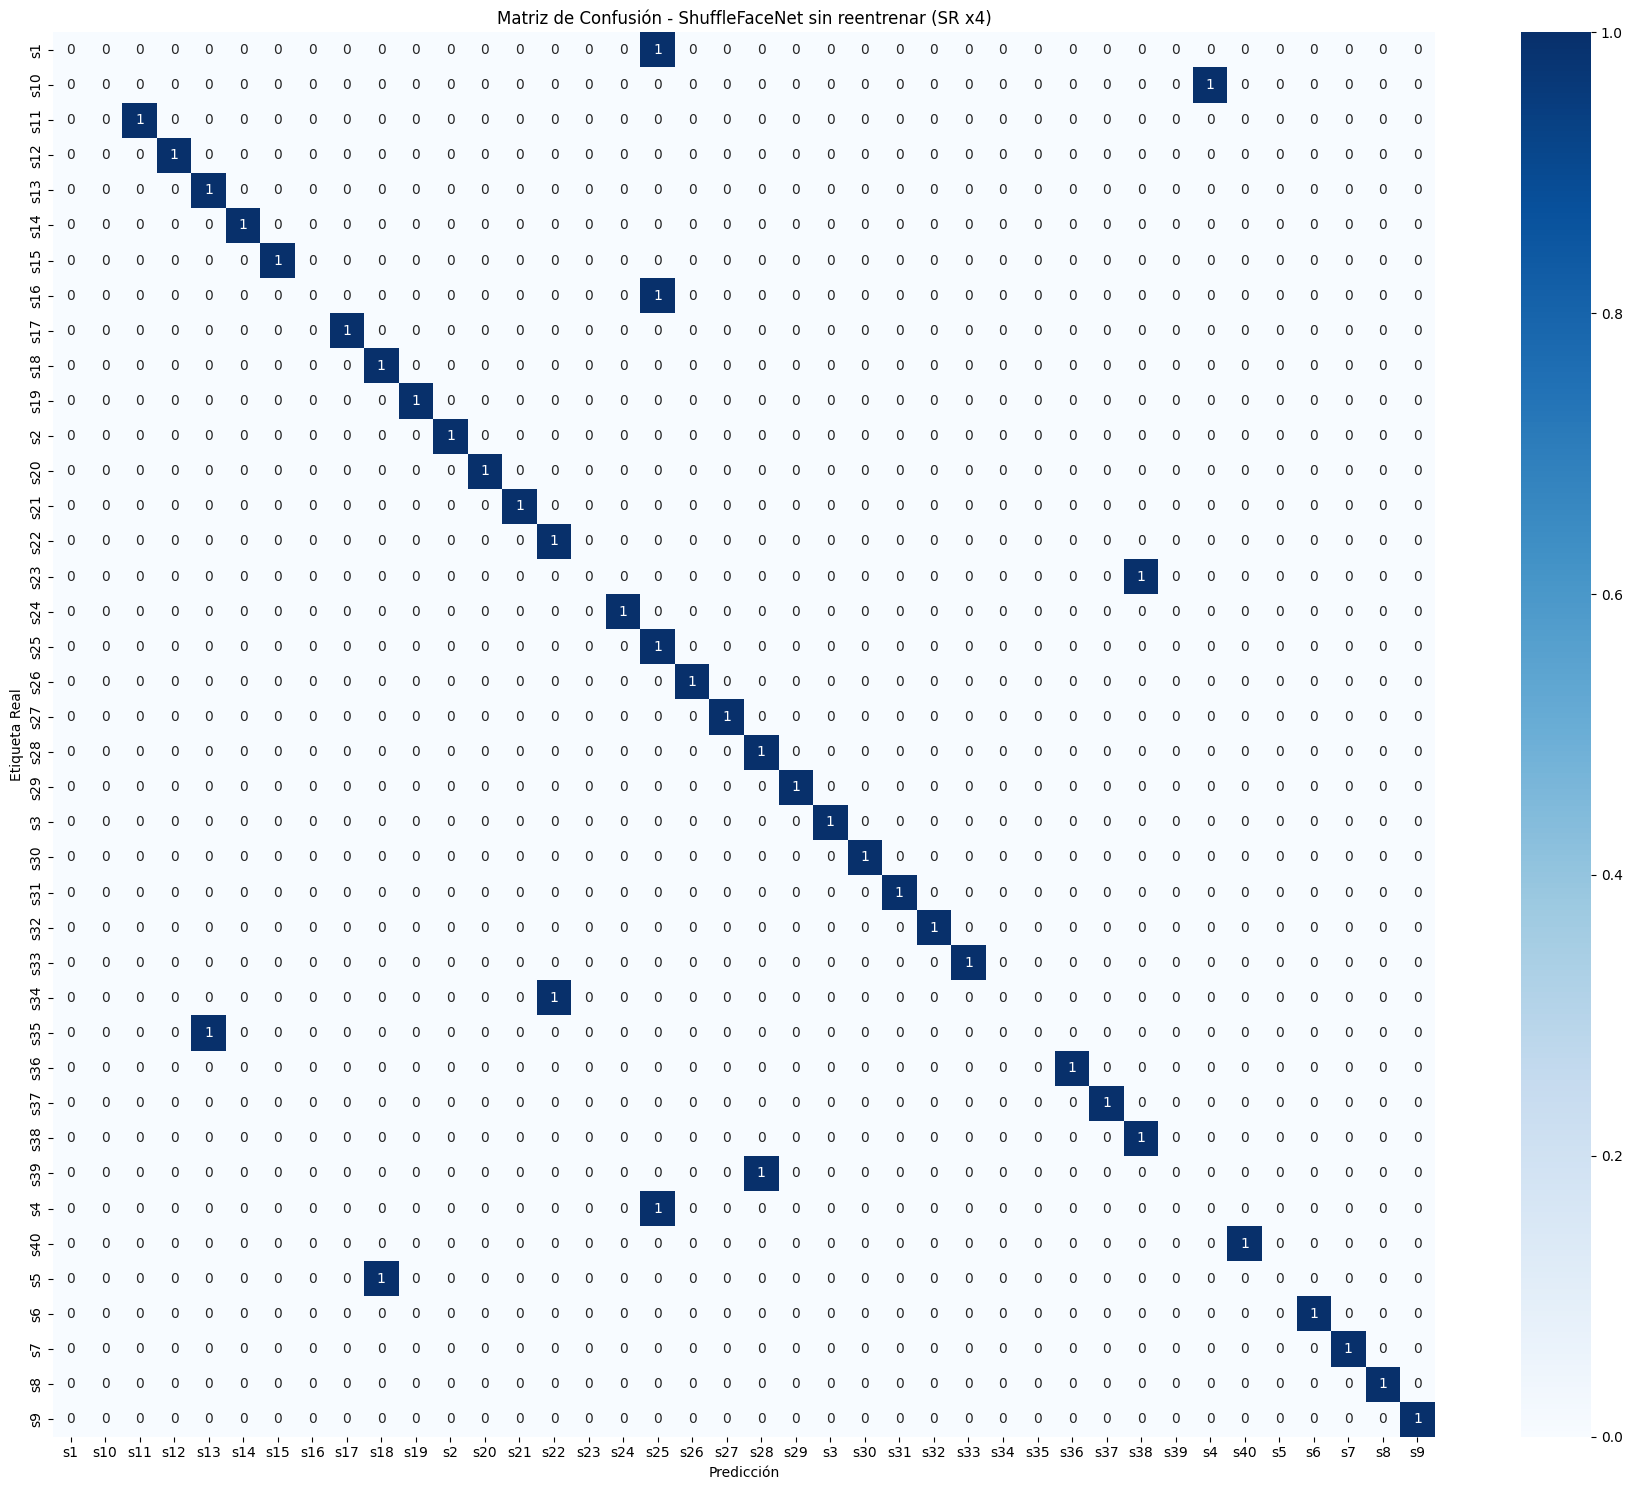

In [9]:
cm = confusion_matrix(all_labels_Gh, all_preds_Gh)
plt.figure(figsize=(18, 15))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=SR_x4_class_names,
            yticklabels=SR_x4_class_names)
plt.title("Matriz de Confusión - ShuffleFaceNet sin reentrenar (SR x4)")
plt.xlabel("Predicción")
plt.ylabel("Etiqueta Real")
plt.tight_layout()
plt.show()


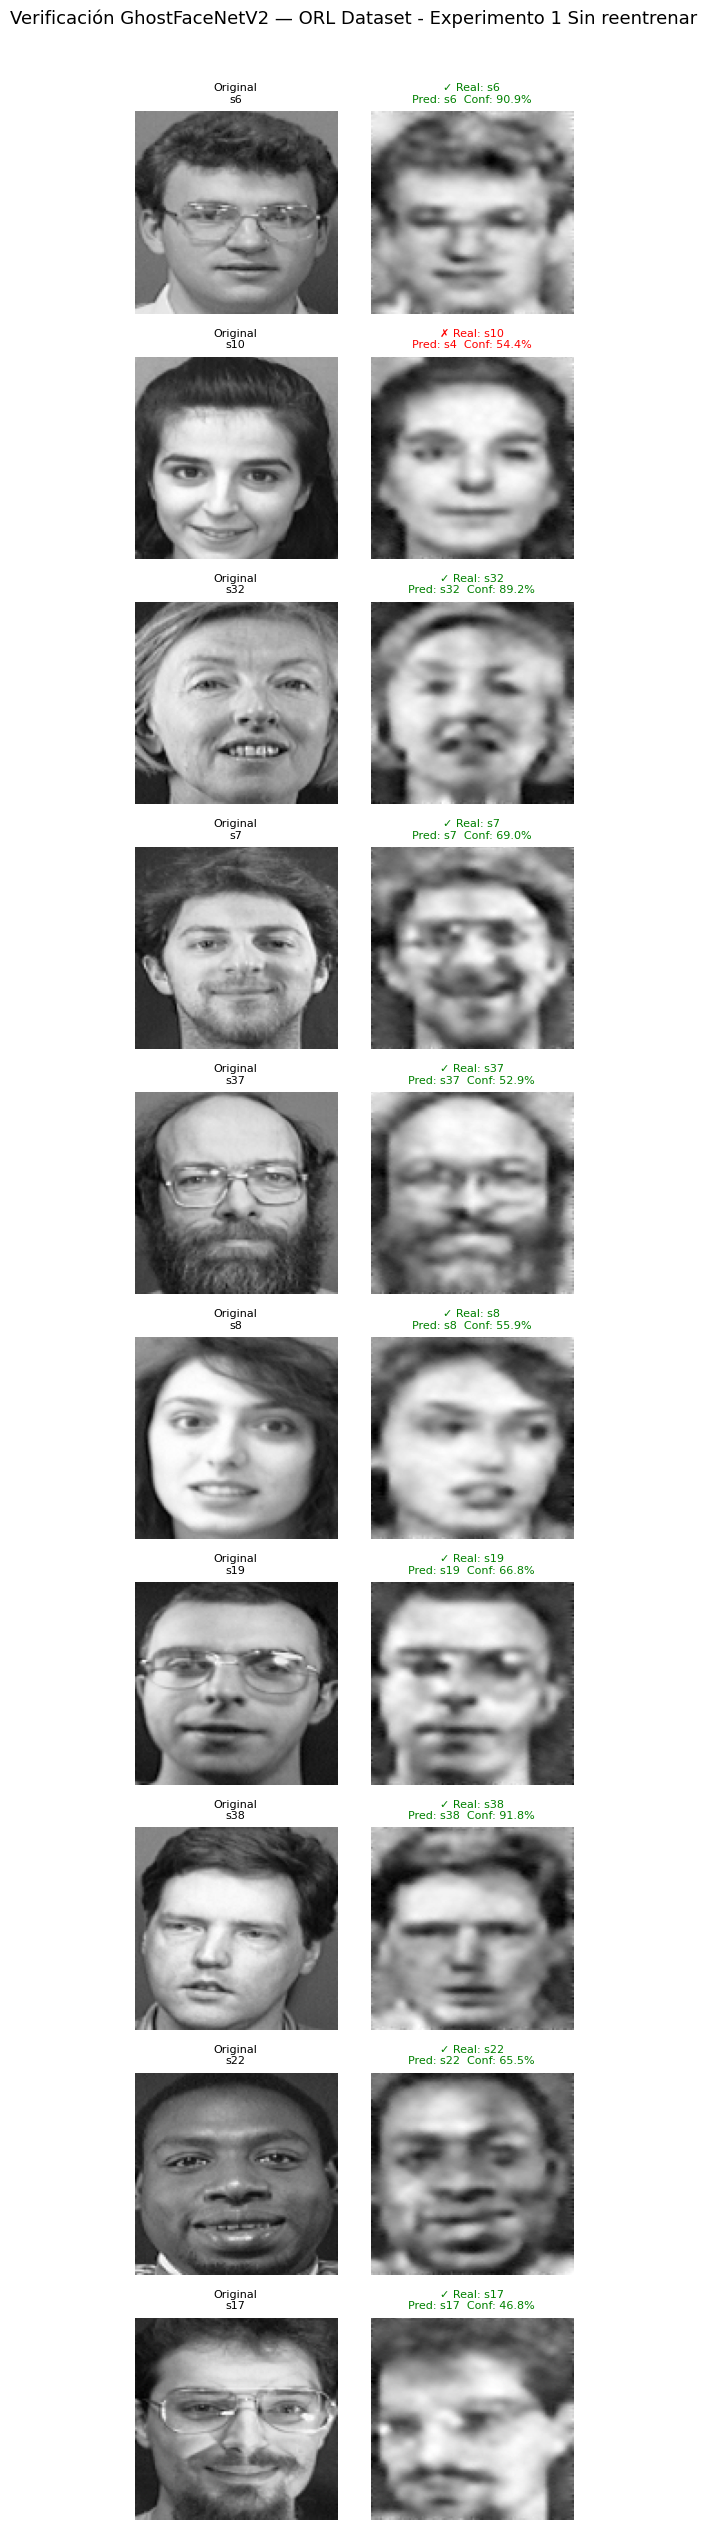


--- Resumen de verificación ---
Identificados correctamente : 31/40
Accuracy total              : 77.50%


In [10]:
def plot_verification(SR_x4_train_dataset, SR_x4_test_dataset, model, n=10):
    model.eval()
    clean_transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((IMG_HEIGHT, IMG_WIDTH)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5]),
    ])
 
    train_dataset_clean = datasets.ImageFolder(TRAIN_PATH, transform=clean_transform)
 
    train_reference = {}
    for img, label in train_dataset_clean:
        if label not in train_reference:
            train_reference[label] = img
 
    # Seleccionar n sujetos aleatorios del test
    indices = np.random.choice(len(SR_x4_test_dataset), n, replace=False)
 
    fig, axes = plt.subplots(n, 2, figsize=(5, n * 2.5))
    fig.suptitle("Verificación GhostFaceNetV2 — ORL Dataset - Experimento 1 Sin reentrenar", fontsize=13, y=1.01)
 
    with torch.no_grad():
        for row, idx in enumerate(indices):
            img_test, label = SR_x4_test_dataset[idx]
 
            # Predicción con confianza
            logits  = model(img_test.unsqueeze(0).to(DEVICE))
            probs   = torch.softmax(logits, dim=1)
            conf, pred = probs.max(1)
            pred    = pred.item()
            conf    = conf.item() * 100
 
            # Desnormalizar para visualizar
            def denorm(t):
                return (t.squeeze().cpu().numpy() * 0.5 + 0.5).clip(0, 1)
 
            img_train_show = denorm(train_reference[label])
            img_test_show  = denorm(img_test)
 
            correct = (pred == label)
            color   = 'green' if correct else 'red'
            symbol  = '✓' if correct else '✗'
 
            # ---- Columna izquierda: imagen de referencia (train) ----
            axes[row, 0].imshow(img_train_show, cmap='gray')
            axes[row, 0].set_title(f"Original\n{SR_x4_class_names[label]}", fontsize=8)
            axes[row, 0].axis('off')
 
            # ---- Columna derecha: imagen de test + resultado ----
            axes[row, 1].imshow(img_test_show, cmap='gray')
            axes[row, 1].set_title(f"{symbol} Real: {SR_x4_class_names[label]}\nPred: {SR_x4_class_names[pred]}  Conf: {conf:.1f}%",
                fontsize=8, color=color
            )
            axes[row, 1].axis('off')
 
    plt.tight_layout()
    plt.show()
 
    # Resumen numérico
    print("\n--- Resumen de verificación ---")
    correct_total = 0
    with torch.no_grad():
        for img_test, label in SR_x4_test_dataset:
            logits = model(img_test.unsqueeze(0).to(DEVICE))
            pred   = logits.argmax(1).item()
            if pred == label:
                correct_total += 1
    print(f"Identificados correctamente : {correct_total}/{len(SR_x4_test_dataset)}")
    print(f"Accuracy total              : {correct_total/len(SR_x4_test_dataset)*100:.2f}%")
 
 
plot_verification(SR_x4_train_dataset, SR_x4_test_dataset, model_ref_Gh, n=10)

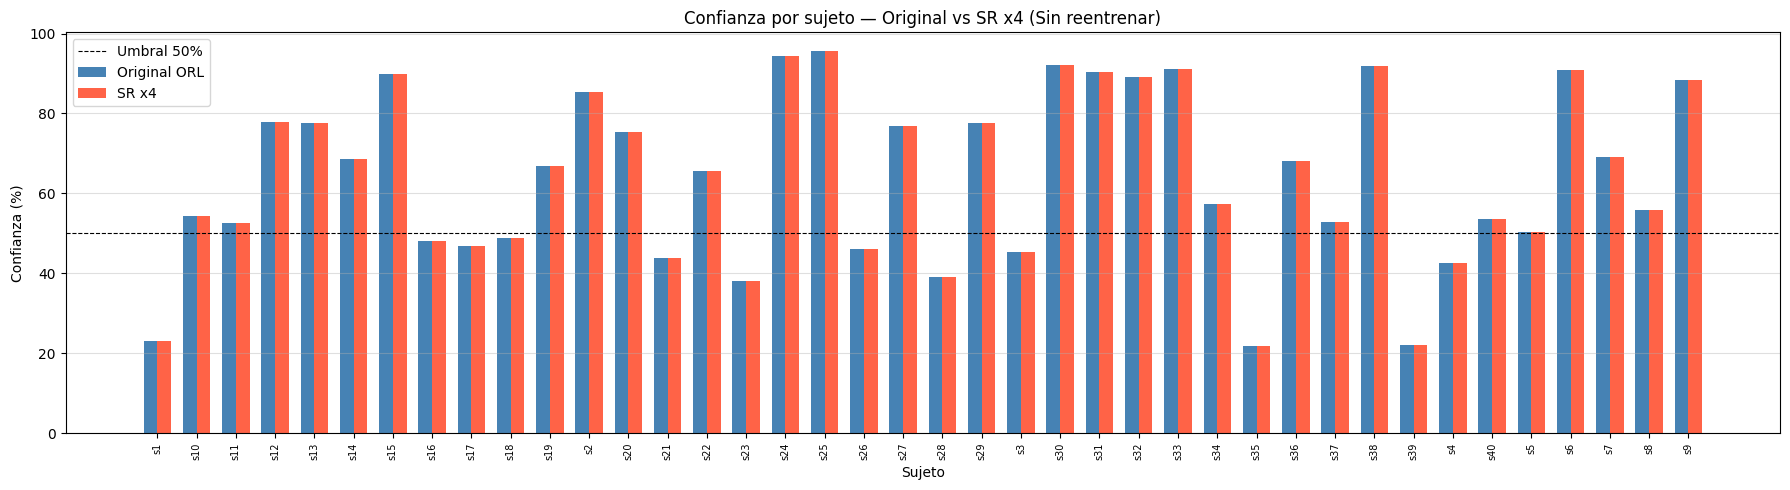

In [11]:
from collections import defaultdict

confs_por_label = defaultdict(list)
model_ref_Gh.eval()
with torch.no_grad():
    for img_test, label in SR_x4_test_dataset:
        logits = model_ref_Gh(img_test.unsqueeze(0).to(DEVICE))
        probs  = torch.softmax(logits, dim=1)
        conf, _ = probs.max(1)
        confs_por_label[label].append(conf.item() * 100)

confs_original = np.array([np.mean(confs_por_label[i]) for i in range(NUM_CLASSES)])
confs_SR_x4_por_label = defaultdict(list)
for lbl, conf in zip(all_labels_Gh, all_confs_Gh):
    confs_SR_x4_por_label[lbl].append(conf)
confs_SR_x4 = np.array([np.mean(confs_SR_x4_por_label[i]) for i in range(NUM_CLASSES)])

# Nombres reales de las clases, en el mismo orden (0..NUM_CLASSES-1)
subjects = [SR_x4_class_names[i] for i in range(NUM_CLASSES)]

x = np.arange(NUM_CLASSES)
width = 0.35

fig, ax = plt.subplots(figsize=(18, 5))
ax.bar(x - width/2, confs_original, width, label='Original ORL', color='steelblue')
ax.bar(x + width/2, confs_SR_x4,    width, label='SR x4',        color='tomato')

ax.set_xlabel('Sujeto')
ax.set_ylabel('Confianza (%)')
ax.set_title('Confianza por sujeto — Original vs SR x4 (Sin reentrenar)')
ax.set_xticks(x)
ax.set_xticklabels(subjects, rotation=90, fontsize=7)
ax.axhline(y=50, color='black', linestyle='--', linewidth=0.8, label='Umbral 50%')
ax.legend()
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

# Experimento 2 Entrenamiento del modelo con SR x4 y CrossEntropy

In [12]:
model_SR_x4 = GhostFaceNetV2(num_classes=NUM_CLASSES, use_dfc=True).to(DEVICE)
 
orl_state   = torch.load("best_ghostfacenet_orl.pth", map_location=DEVICE)
model_state = model_SR_x4.state_dict()
compatible_state = {
    k: v for k, v in orl_state.items()
    if k in model_state and v.shape == model_state[k].shape
}
model_state.update(compatible_state)
model_SR_x4.load_state_dict(model_state)
print(f"\nPesos ORL cargados: {len(compatible_state)}/{len(model_state)} capas compatibles")
 
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.SGD(model_SR_x4.parameters(), lr=LEARNING_RATE,
                             momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
 
warmup_epochs = 5
def lr_lambda(epoch):
    if epoch < warmup_epochs:
        return (epoch + 1) / warmup_epochs
    return 1.0
 
warmup_scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)
cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS - warmup_epochs)


Pesos ORL cargados: 448/448 capas compatibles


In [13]:
history_SR_x4 = {
    "train_loss": [], "train_acc": [],
    "val_loss": [], "val_acc": [],
    "lr": [], "best_acc": 0.0, "best_epoch": 0
}
 
best_acc = 0.0
patience = 12
counter  = 0
 
for epoch in range(EPOCHS):
    model_SR_x4.train()
    running_loss, correct, total = 0.0, 0, 0
 
    for images, labels in SR_x4_train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
 
        optimizer.zero_grad()
        outputs = model_SR_x4(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
 
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
 
    train_loss = running_loss / total
    train_acc  = 100 * correct / total
 
    model_SR_x4.eval()
    running_loss, correct, total = 0.0, 0, 0
 
    with torch.no_grad():
        for images, labels in SR_x4_test_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model_SR_x4(images)
            loss = criterion(outputs, labels)
 
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
 
    val_loss = running_loss / total
    val_acc  = 100 * correct / total
 
    if epoch < warmup_epochs:
        warmup_scheduler.step()
    else:
        cosine_scheduler.step()
 
    current_lr = optimizer.param_groups[0]['lr']
 
    history_SR_x4["train_loss"].append(train_loss)
    history_SR_x4["train_acc"].append(train_acc)
    history_SR_x4["val_loss"].append(val_loss)
    history_SR_x4["val_acc"].append(val_acc)
    history_SR_x4["lr"].append(current_lr)
 
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | LR: {current_lr:.6f} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}%")
 
    if val_acc > best_acc:
        best_acc = val_acc
        history_SR_x4["best_acc"] = best_acc
        history_SR_x4["best_epoch"] = epoch + 1
        counter = 0
        torch.save(model_SR_x4.state_dict(), "best_ghostfacenet_SR_x4_experimento2.pth")
    else:
        counter += 1
        if counter >= patience:
            print(f"\nEarly stopping en epoch {epoch+1} (sin mejora por {patience} epochs)")
            break
 
print(f"\nMejor Val Accuracy: {history_SR_x4['best_acc']:.2f}% (Epoch {history_SR_x4['best_epoch']})")
 

with open("history_ghostfacenet_SR_x4_experimento2.json", "w") as f:
    json.dump(history_SR_x4, f, indent=2)

Epoch 01/50 | LR: 0.004000 | Train Loss: 0.9983 Acc: 95.56% | Val Loss: 1.2979 Acc: 82.50%
Epoch 02/50 | LR: 0.006000 | Train Loss: 0.9420 Acc: 97.50% | Val Loss: 1.2864 Acc: 82.50%
Epoch 03/50 | LR: 0.008000 | Train Loss: 0.9263 Acc: 98.89% | Val Loss: 1.2561 Acc: 85.00%
Epoch 04/50 | LR: 0.010000 | Train Loss: 0.9360 Acc: 97.78% | Val Loss: 1.3487 Acc: 85.00%
Epoch 05/50 | LR: 0.010000 | Train Loss: 0.9404 Acc: 97.22% | Val Loss: 1.2904 Acc: 87.50%
Epoch 06/50 | LR: 0.009988 | Train Loss: 0.9546 Acc: 95.83% | Val Loss: 1.3786 Acc: 77.50%
Epoch 07/50 | LR: 0.009951 | Train Loss: 0.9210 Acc: 98.61% | Val Loss: 1.2997 Acc: 87.50%
Epoch 08/50 | LR: 0.009891 | Train Loss: 0.9261 Acc: 97.50% | Val Loss: 1.3602 Acc: 80.00%
Epoch 09/50 | LR: 0.009806 | Train Loss: 0.8851 Acc: 99.17% | Val Loss: 1.2817 Acc: 77.50%
Epoch 10/50 | LR: 0.009698 | Train Loss: 0.8757 Acc: 98.89% | Val Loss: 1.1981 Acc: 85.00%
Epoch 11/50 | LR: 0.009568 | Train Loss: 0.8778 Acc: 98.89% | Val Loss: 1.1977 Acc: 85.00%

In [15]:
model_SR_x4.load_state_dict(torch.load("best_ghostfacenet_SR_x4_experimento2.pth", map_location=DEVICE))
model_SR_x4.eval()
 
all_preds, all_labels, all_confs = [], [], []
 
with torch.no_grad():
    for images, labels in SR_x4_test_loader:
        images = images.to(DEVICE)
        outputs = model_SR_x4(images)
        probs = F.softmax(outputs, dim=1)
        confs, preds = torch.max(probs, dim=1)
 
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_confs.extend(confs.cpu().numpy())
 
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_confs  = np.array(all_confs) * 100
 
final_acc = 100 * np.sum(all_preds == all_labels) / len(all_labels)
print(f"\n=== [SR x4] Experimento 2 — Reentrenado (CE) ===")
print(f"Accuracy final en Test: {final_acc:.2f}%")
print(f"Confianza promedio: {all_confs.mean():.2f}%")
print(f"Confianza mínima  : {all_confs.min():.2f}%")
print(f"Confianza máxima  : {all_confs.max():.2f}%")
print(f"Desviación estándar: {all_confs.std():.2f}%")
print("\n" + "="*60)
print("REPORTE DE CLASIFICACIÓN")
print("="*60)
print(classification_report(all_labels, all_preds, target_names=SR_x4_class_names, zero_division=0))
 


=== [SR x4] Experimento 2 — Reentrenado (CE) ===
Accuracy final en Test: 87.50%
Confianza promedio: 67.00%
Confianza mínima  : 20.89%
Confianza máxima  : 94.37%
Desviación estándar: 23.34%

REPORTE DE CLASIFICACIÓN
              precision    recall  f1-score   support

          s1       1.00      1.00      1.00         1
         s10       0.00      0.00      0.00         1
         s11       1.00      1.00      1.00         1
         s12       1.00      1.00      1.00         1
         s13       0.50      1.00      0.67         1
         s14       1.00      1.00      1.00         1
         s15       1.00      1.00      1.00         1
         s16       1.00      1.00      1.00         1
         s17       1.00      1.00      1.00         1
         s18       0.50      1.00      0.67         1
         s19       1.00      1.00      1.00         1
          s2       1.00      1.00      1.00         1
         s20       1.00      1.00      1.00         1
         s21       1.00    

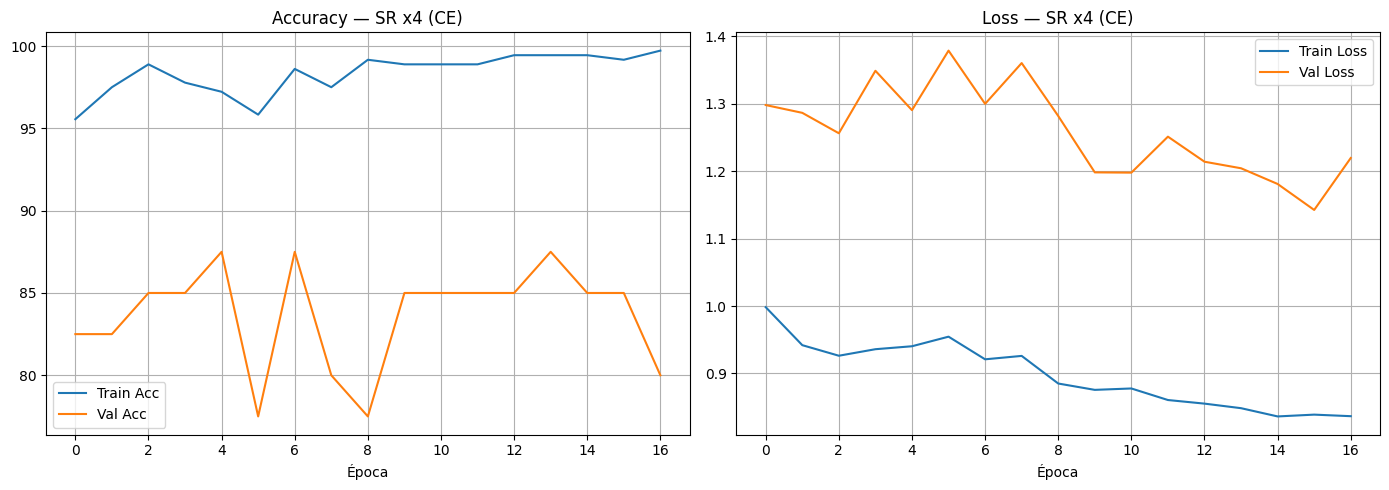

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
axes[0].plot(history_SR_x4['train_acc'], label='Train Acc')
axes[0].plot(history_SR_x4['val_acc'],   label='Val Acc')
axes[0].set_title('Accuracy — SR x4 (CE)')
axes[0].set_xlabel('Época')
axes[0].legend(); axes[0].grid(True)
 
axes[1].plot(history_SR_x4['train_loss'], label='Train Loss')
axes[1].plot(history_SR_x4['val_loss'],   label='Val Loss')
axes[1].set_title('Loss — SR x4 (CE)')
axes[1].set_xlabel('Época')
axes[1].legend(); axes[1].grid(True)
 
plt.tight_layout()
plt.show()

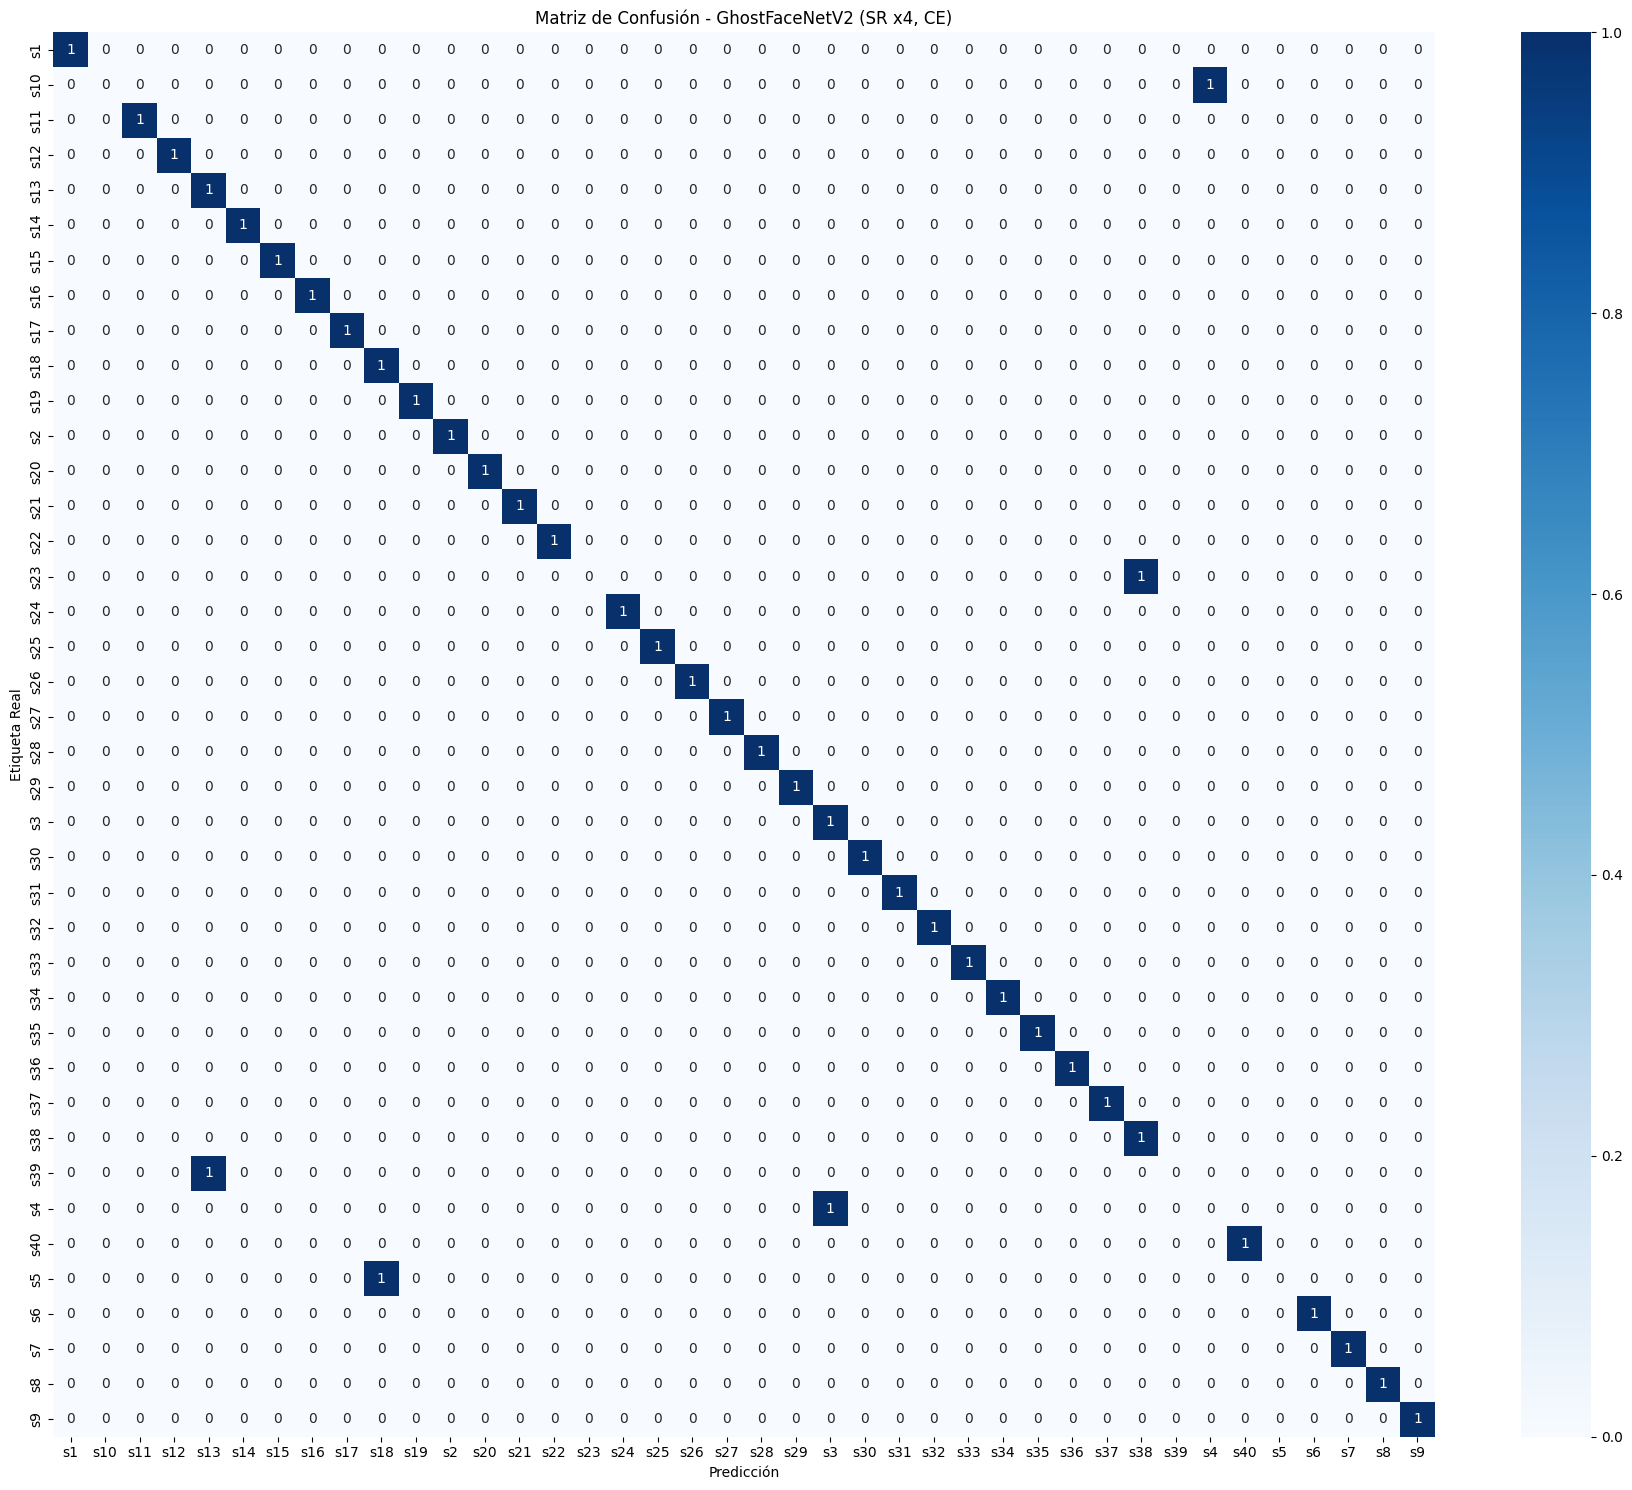

In [17]:
cm = confusion_matrix(all_labels, all_preds)
 
plt.figure(figsize=(18, 15))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=SR_x4_class_names,
            yticklabels=SR_x4_class_names)
plt.title("Matriz de Confusión - GhostFaceNetV2 (SR x4, CE)")
plt.xlabel("Predicción")
plt.ylabel("Etiqueta Real")
plt.tight_layout()
plt.show()

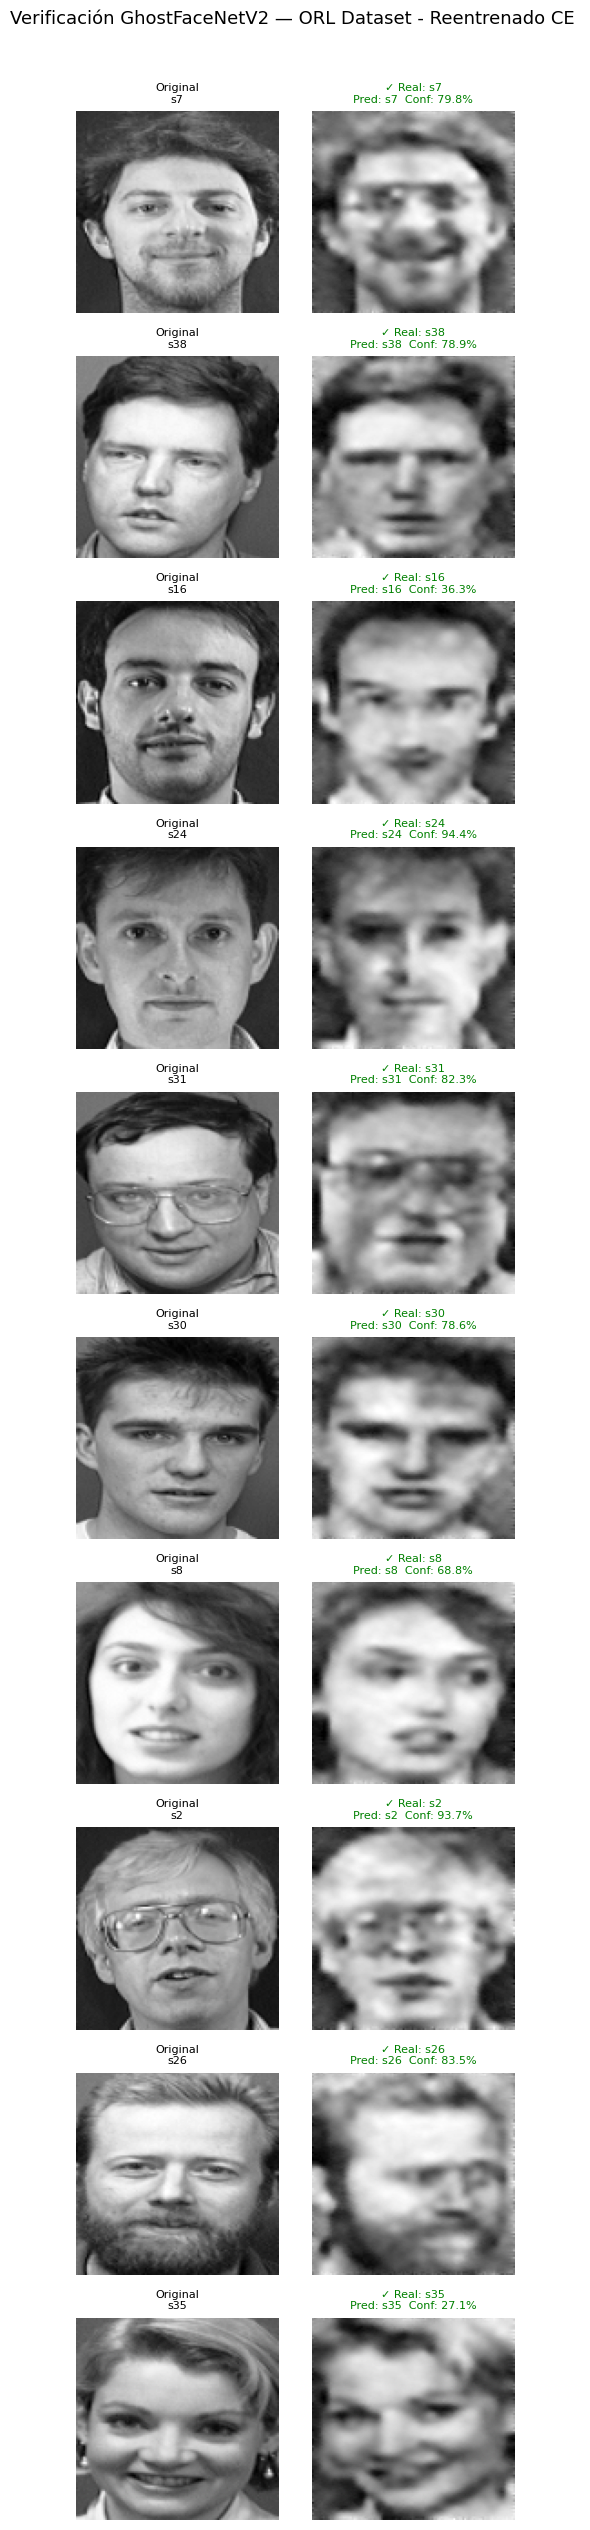


--- Resumen de verificación ---
Identificados correctamente : 35/40
Accuracy total              : 87.50%


In [18]:
def plot_verification(SR_x4_train_dataset, SR_x4_test_dataset, model, n=10):
    model.eval()
    clean_transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((IMG_HEIGHT, IMG_WIDTH)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5]),
    ])
 
    train_dataset_clean = datasets.ImageFolder(TRAIN_PATH, transform=clean_transform)
 
    train_reference = {}
    for img, label in train_dataset_clean:
        if label not in train_reference:
            train_reference[label] = img
 
    # Seleccionar n sujetos aleatorios del test
    indices = np.random.choice(len(SR_x4_test_dataset), n, replace=False)
 
    fig, axes = plt.subplots(n, 2, figsize=(5, n * 2.5))
    fig.suptitle("Verificación GhostFaceNetV2 — ORL Dataset - Reentrenado CE ", fontsize=13, y=1.01)
 
    with torch.no_grad():
        for row, idx in enumerate(indices):
            img_test, label = SR_x4_test_dataset[idx]
 
            # Predicción con confianza
            logits  = model(img_test.unsqueeze(0).to(DEVICE))
            probs   = torch.softmax(logits, dim=1)
            conf, pred = probs.max(1)
            pred    = pred.item()
            conf    = conf.item() * 100
 
            # Desnormalizar para visualizar
            def denorm(t):
                return (t.squeeze().cpu().numpy() * 0.5 + 0.5).clip(0, 1)
 
            img_train_show = denorm(train_reference[label])
            img_test_show  = denorm(img_test)
 
            correct = (pred == label)
            color   = 'green' if correct else 'red'
            symbol  = '✓' if correct else '✗'
 
            # ---- Columna izquierda: imagen de referencia (train) ----
            axes[row, 0].imshow(img_train_show, cmap='gray')
            axes[row, 0].set_title(f"Original\n{SR_x4_class_names[label]}", fontsize=8)
            axes[row, 0].axis('off')
 
            # ---- Columna derecha: imagen de test + resultado ----
            axes[row, 1].imshow(img_test_show, cmap='gray')
            axes[row, 1].set_title(f"{symbol} Real: {SR_x4_class_names[label]}\nPred: {SR_x4_class_names[pred]}  Conf: {conf:.1f}%",
                fontsize=8, color=color
            )
            axes[row, 1].axis('off')
 
    plt.tight_layout()
    plt.show()
 
    # Resumen numérico
    print("\n--- Resumen de verificación ---")
    correct_total = 0
    with torch.no_grad():
        for img_test, label in SR_x4_test_dataset:
            logits = model_SR_x4(img_test.unsqueeze(0).to(DEVICE))
            pred   = logits.argmax(1).item()
            if pred == label:
                correct_total += 1
    print(f"Identificados correctamente : {correct_total}/{len(SR_x4_test_dataset)}")
    print(f"Accuracy total              : {correct_total/len(SR_x4_test_dataset)*100:.2f}%")
 
 
plot_verification(SR_x4_train_dataset, SR_x4_test_dataset, model_SR_x4, n=10)

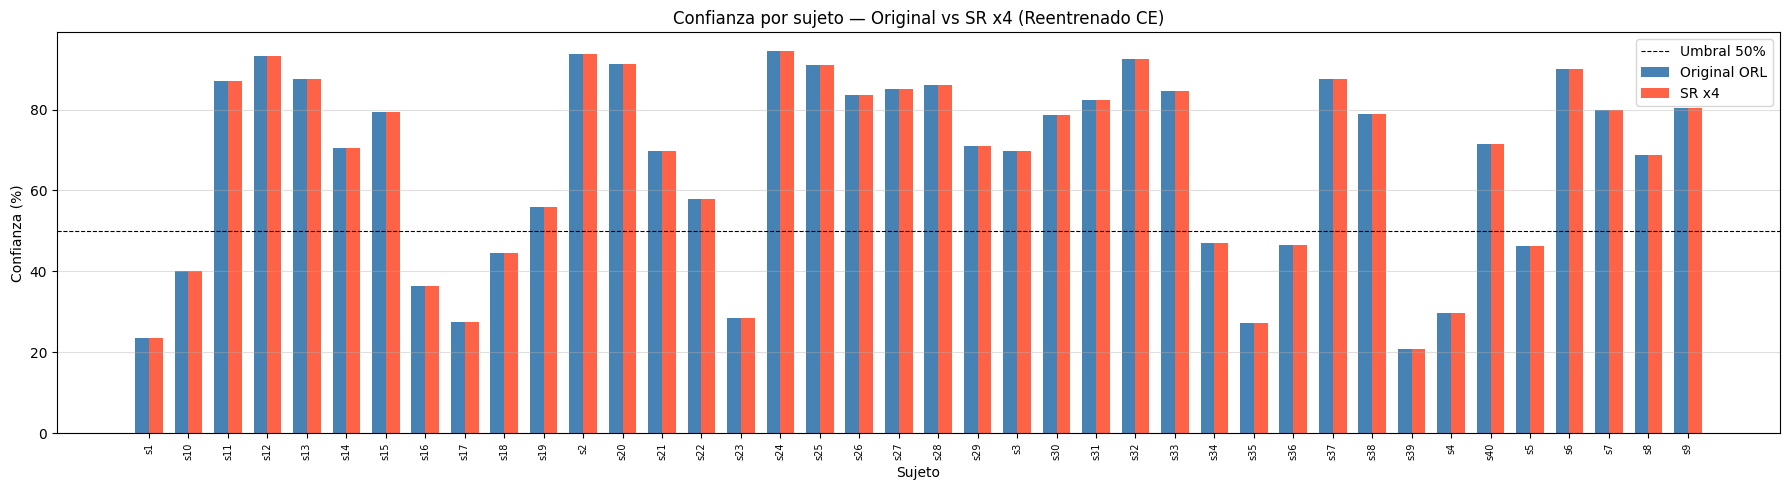

In [19]:
from collections import defaultdict

confs_por_label = defaultdict(list)
model_SR_x4.eval()
with torch.no_grad():
    for img_test, label in SR_x4_test_dataset:
        logits = model_SR_x4(img_test.unsqueeze(0).to(DEVICE))
        probs  = torch.softmax(logits, dim=1)
        conf, _ = probs.max(1)
        confs_por_label[label].append(conf.item() * 100)

# Promedio de confianza por sujeto, en el orden correcto de labels (0..NUM_CLASSES-1)
confs_original = np.array([np.mean(confs_por_label[i]) for i in range(NUM_CLASSES)])

# Lo mismo para las confianzas CLAHE x2 (usa all_labels / all_confs de la celda de evaluación)
confs_SR_x4_por_label = defaultdict(list)
for lbl, conf in zip(all_labels, all_confs):
    confs_SR_x4_por_label[lbl].append(conf)
confs_SR_x4 = np.array([np.mean(confs_SR_x4_por_label[i]) for i in range(NUM_CLASSES)])

# Nombres reales de las clases, en el mismo orden (0..NUM_CLASSES-1)
subjects = [SR_x4_class_names[i] for i in range(NUM_CLASSES)]

x = np.arange(NUM_CLASSES)
width = 0.35

fig, ax = plt.subplots(figsize=(18, 5))
ax.bar(x - width/2, confs_original, width, label='Original ORL', color='steelblue')
ax.bar(x + width/2, confs_SR_x4,    width, label='SR x4',        color='tomato')

ax.set_xlabel('Sujeto')
ax.set_ylabel('Confianza (%)')
ax.set_title('Confianza por sujeto — Original vs SR x4 (Reentrenado CE)')
ax.set_xticks(x)
ax.set_xticklabels(subjects, rotation=90, fontsize=7)
ax.axhline(y=50, color='black', linestyle='--', linewidth=0.8, label='Umbral 50%')
ax.legend()
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

# Experimento 3 Entrenamiento del modelo con la función ArcFace(función base de GhostFaceNet)

In [20]:
EMBEDDING_DIM = 128
ARCFACE_S     = 30.0
ARCFACE_M     = 0.50
EARLY_STOP    = 15   

In [21]:
# ---------------------------------------------------------------------------
# Cabeza ArcFace 
# ---------------------------------------------------------------------------
class ArcMarginProduct(nn.Module):
    def __init__(self, in_features, out_features, s=ARCFACE_S, m=ARCFACE_M):
        super().__init__()
        self.s = s
        self.m = m
        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.01)
        self.cos_m = math.cos(m)
        self.sin_m = math.sin(m)
        self.th = math.cos(math.pi - m)
        self.mm = math.sin(math.pi - m) * m
 
    def forward(self, embeddings, labels=None):
        w = F.normalize(self.weight, p=2, dim=1)
        cosine = F.linear(embeddings, w)  # (B, num_classes)
 
        if labels is None:
            return cosine * self.s
 
        sine = torch.sqrt((1.0 - cosine.pow(2)).clamp(0, 1))
        phi = cosine * self.cos_m - sine * self.sin_m
        phi = torch.where(cosine > self.th, phi, cosine - self.mm)
 
        one_hot = torch.zeros_like(cosine)
        one_hot.scatter_(1, labels.view(-1, 1), 1)
        logits = one_hot * phi + (1.0 - one_hot) * cosine
        return logits * self.s
 
 
def extract_embedding(model, x):
    """Corre el backbone hasta el embedding 128-D normalizado,
    saltando el classifier/dropout (que no se usan con ArcFace)."""
    x = model.stem(x)
    x = model.stage1(x)
    x = model.stage2(x)
    x = model.stage3(x)
    x = model.stage4(x)
    x = model.conv_expand(x)
    x = model.gdc(x)
    x = model.embedding(x)
    x = F.normalize(x, p=2, dim=1)
    return x

In [22]:
model_arcface = GhostFaceNetV2(num_classes=NUM_CLASSES, use_dfc=True).to(DEVICE)
 
orl_state   = torch.load("best_ghostfacenet_orl.pth", map_location=DEVICE)
model_state = model_arcface.state_dict()
compatible_state = {
    k: v for k, v in orl_state.items()
    if k in model_state and v.shape == model_state[k].shape
}
model_state.update(compatible_state)
model_arcface.load_state_dict(model_state)
 
head = ArcMarginProduct(EMBEDDING_DIM, NUM_CLASSES, s=ARCFACE_S, m=ARCFACE_M).to(DEVICE)

In [23]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
params = list(model_arcface.parameters()) + list(head.parameters())
optimizer = torch.optim.SGD(params, lr=LEARNING_RATE, momentum=MOMENTUM,
                             weight_decay=WEIGHT_DECAY)
 
warmup_epochs = 5
def lr_lambda(epoch):
    if epoch < warmup_epochs:
        return (epoch + 1) / warmup_epochs
    return 1.0
 
warmup_scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)
cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS - warmup_epochs)

In [24]:
import copy
history_arcface = {
    "train_loss": [], "train_acc": [],
    "val_loss": [], "val_acc": [],
    "lr": [], "best_acc": 0.0, "best_epoch": 0
}
 
best_acc = 0.0
patience = EARLY_STOP
counter  = 0
best_state = None
 
for epoch in range(EPOCHS):
    model_arcface.train()
    head.train()
    running_loss, correct, total = 0.0, 0, 0
 
    for images, labels in SR_x4_train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
 
        optimizer.zero_grad()
        emb = extract_embedding(model_arcface, images)
        logits = head(emb, labels)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
 
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(logits, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
 
    train_loss = running_loss / total
    train_acc  = 100 * correct / total
 
    model_arcface.eval()
    head.eval()
    running_loss, correct, total = 0.0, 0, 0
 
    with torch.no_grad():
        for images, labels in SR_x4_test_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            emb = extract_embedding(model_arcface, images)
            logits = head(emb)  # sin labels -> solo cosine * s (inferencia)
            loss = criterion(logits, labels)
 
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(logits, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
 
    val_loss = running_loss / total
    val_acc  = 100 * correct / total
 
    if epoch < warmup_epochs:
        warmup_scheduler.step()
    else:
        cosine_scheduler.step()
 
    current_lr = optimizer.param_groups[0]['lr']
 
    history_arcface["train_loss"].append(train_loss)
    history_arcface["train_acc"].append(train_acc)
    history_arcface["val_loss"].append(val_loss)
    history_arcface["val_acc"].append(val_acc)
    history_arcface["lr"].append(current_lr)
 
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | LR: {current_lr:.6f} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}%")
 
    if val_acc > best_acc:
        best_acc = val_acc
        history_arcface["best_acc"] = best_acc
        history_arcface["best_epoch"] = epoch + 1
        counter = 0
        best_state = {
            "model": copy.deepcopy(model_arcface.state_dict()),
            "head": copy.deepcopy(head.state_dict()),
        }
        torch.save(best_state, "best_ghostfacenet_arcface_SR_x4_experimento3.pth")
    else:
        counter += 1
        if counter >= patience:
            print(f"\nEarly stopping en epoch {epoch+1} (sin mejora por {patience} epochs)")
            break
 
if best_state is not None:
    model_arcface.load_state_dict(best_state["model"])
    head.load_state_dict(best_state["head"])
 
print(f"\nMejor Val Accuracy (ArcFace): {history_arcface['best_acc']:.2f}% (Epoch {history_arcface['best_epoch']})")

with open("history_ghostfacenet_SR_x4_experimento3.json", "w") as f:
    json.dump(history_arcface, f, indent=2)

Epoch 01/50 | LR: 0.004000 | Train Loss: 11.7209 Acc: 9.44% | Val Loss: 3.6483 Acc: 80.00%
Epoch 02/50 | LR: 0.006000 | Train Loss: 9.1631 Acc: 11.39% | Val Loss: 4.8607 Acc: 57.50%
Epoch 03/50 | LR: 0.008000 | Train Loss: 9.3479 Acc: 13.89% | Val Loss: 4.1241 Acc: 72.50%
Epoch 04/50 | LR: 0.010000 | Train Loss: 8.7394 Acc: 17.22% | Val Loss: 4.4053 Acc: 62.50%
Epoch 05/50 | LR: 0.010000 | Train Loss: 8.3199 Acc: 15.83% | Val Loss: 3.6232 Acc: 72.50%
Epoch 06/50 | LR: 0.009988 | Train Loss: 7.5791 Acc: 22.50% | Val Loss: 3.9353 Acc: 70.00%
Epoch 07/50 | LR: 0.009951 | Train Loss: 5.5917 Acc: 37.22% | Val Loss: 3.6483 Acc: 77.50%
Epoch 08/50 | LR: 0.009891 | Train Loss: 5.1534 Acc: 41.67% | Val Loss: 3.9278 Acc: 70.00%
Epoch 09/50 | LR: 0.009806 | Train Loss: 4.5467 Acc: 48.89% | Val Loss: 3.4520 Acc: 85.00%
Epoch 10/50 | LR: 0.009698 | Train Loss: 3.2478 Acc: 60.00% | Val Loss: 3.0379 Acc: 80.00%
Epoch 11/50 | LR: 0.009568 | Train Loss: 3.1842 Acc: 65.56% | Val Loss: 3.2975 Acc: 87.50%

In [25]:
model_arcface.eval()
head.eval()
 
all_preds, all_labels, all_confs = [], [], []
 
with torch.no_grad():
    for images, labels in SR_x4_test_loader:
        images = images.to(DEVICE)
        emb = extract_embedding(model_arcface, images)
        logits = head(emb)  # inferencia: cosine * s, sin margen
        probs = F.softmax(logits, dim=1)
        confs, preds = torch.max(probs, dim=1)
 
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_confs.extend(confs.cpu().numpy())
 
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_confs  = np.array(all_confs) * 100
 
final_acc_arcface = 100 * np.sum(all_preds == all_labels) / len(all_labels)
print(f"\n=== [SR x4] Experimento 3 — PReLU + ArcFace ===")
print(f"Accuracy final en Test: {final_acc_arcface:.2f}%")
print(f"Confianza promedio: {all_confs.mean():.2f}%")
print(f"Confianza mínima  : {all_confs.min():.2f}%")
print(f"Confianza máxima  : {all_confs.max():.2f}%")
print(f"Desviación estándar: {all_confs.std():.2f}%")
print("\n" + "="*60)
print("REPORTE DE CLASIFICACIÓN")
print("="*60)
print(classification_report(all_labels, all_preds, target_names=SR_x4_class_names, zero_division=0))


=== [SR x4] Experimento 3 — PReLU + ArcFace ===
Accuracy final en Test: 92.50%
Confianza promedio: 96.49%
Confianza mínima  : 59.91%
Confianza máxima  : 100.00%
Desviación estándar: 9.86%

REPORTE DE CLASIFICACIÓN
              precision    recall  f1-score   support

          s1       0.00      0.00      0.00         1
         s10       0.00      0.00      0.00         1
         s11       1.00      1.00      1.00         1
         s12       1.00      1.00      1.00         1
         s13       1.00      1.00      1.00         1
         s14       1.00      1.00      1.00         1
         s15       1.00      1.00      1.00         1
         s16       1.00      1.00      1.00         1
         s17       1.00      1.00      1.00         1
         s18       1.00      1.00      1.00         1
         s19       1.00      1.00      1.00         1
          s2       1.00      1.00      1.00         1
         s20       1.00      1.00      1.00         1
         s21       1.00     

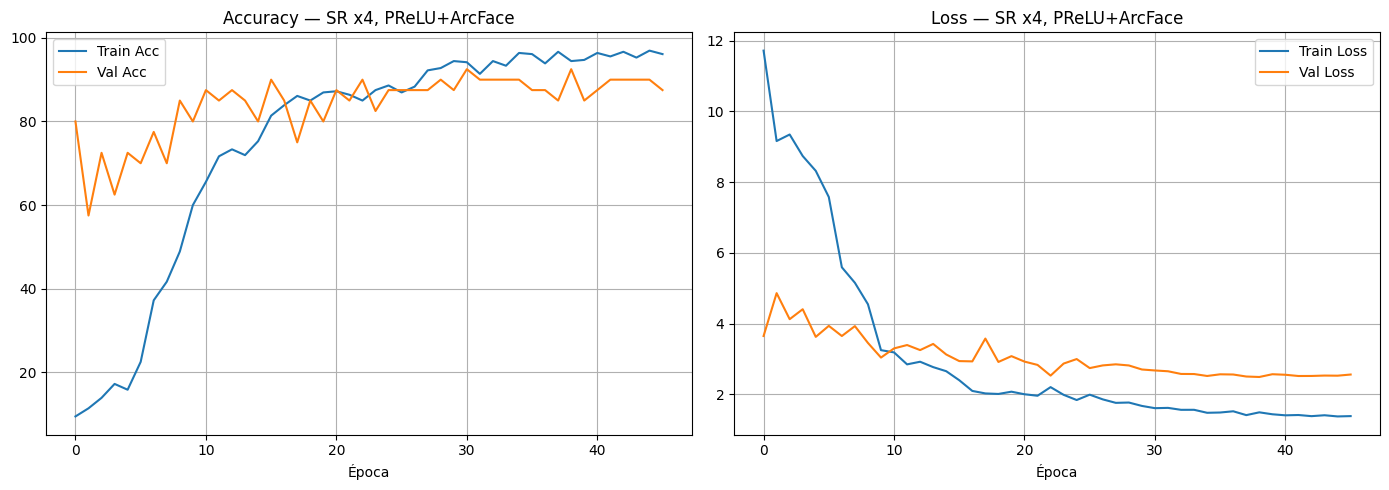

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
axes[0].plot(history_arcface['train_acc'], label='Train Acc')
axes[0].plot(history_arcface['val_acc'],   label='Val Acc')
axes[0].set_title('Accuracy — SR x4, PReLU+ArcFace')
axes[0].set_xlabel('Época')
axes[0].legend(); axes[0].grid(True)
 
axes[1].plot(history_arcface['train_loss'], label='Train Loss')
axes[1].plot(history_arcface['val_loss'],   label='Val Loss')
axes[1].set_title('Loss — SR x4, PReLU+ArcFace')
axes[1].set_xlabel('Época')
axes[1].legend(); axes[1].grid(True)
 
plt.tight_layout()
plt.show()

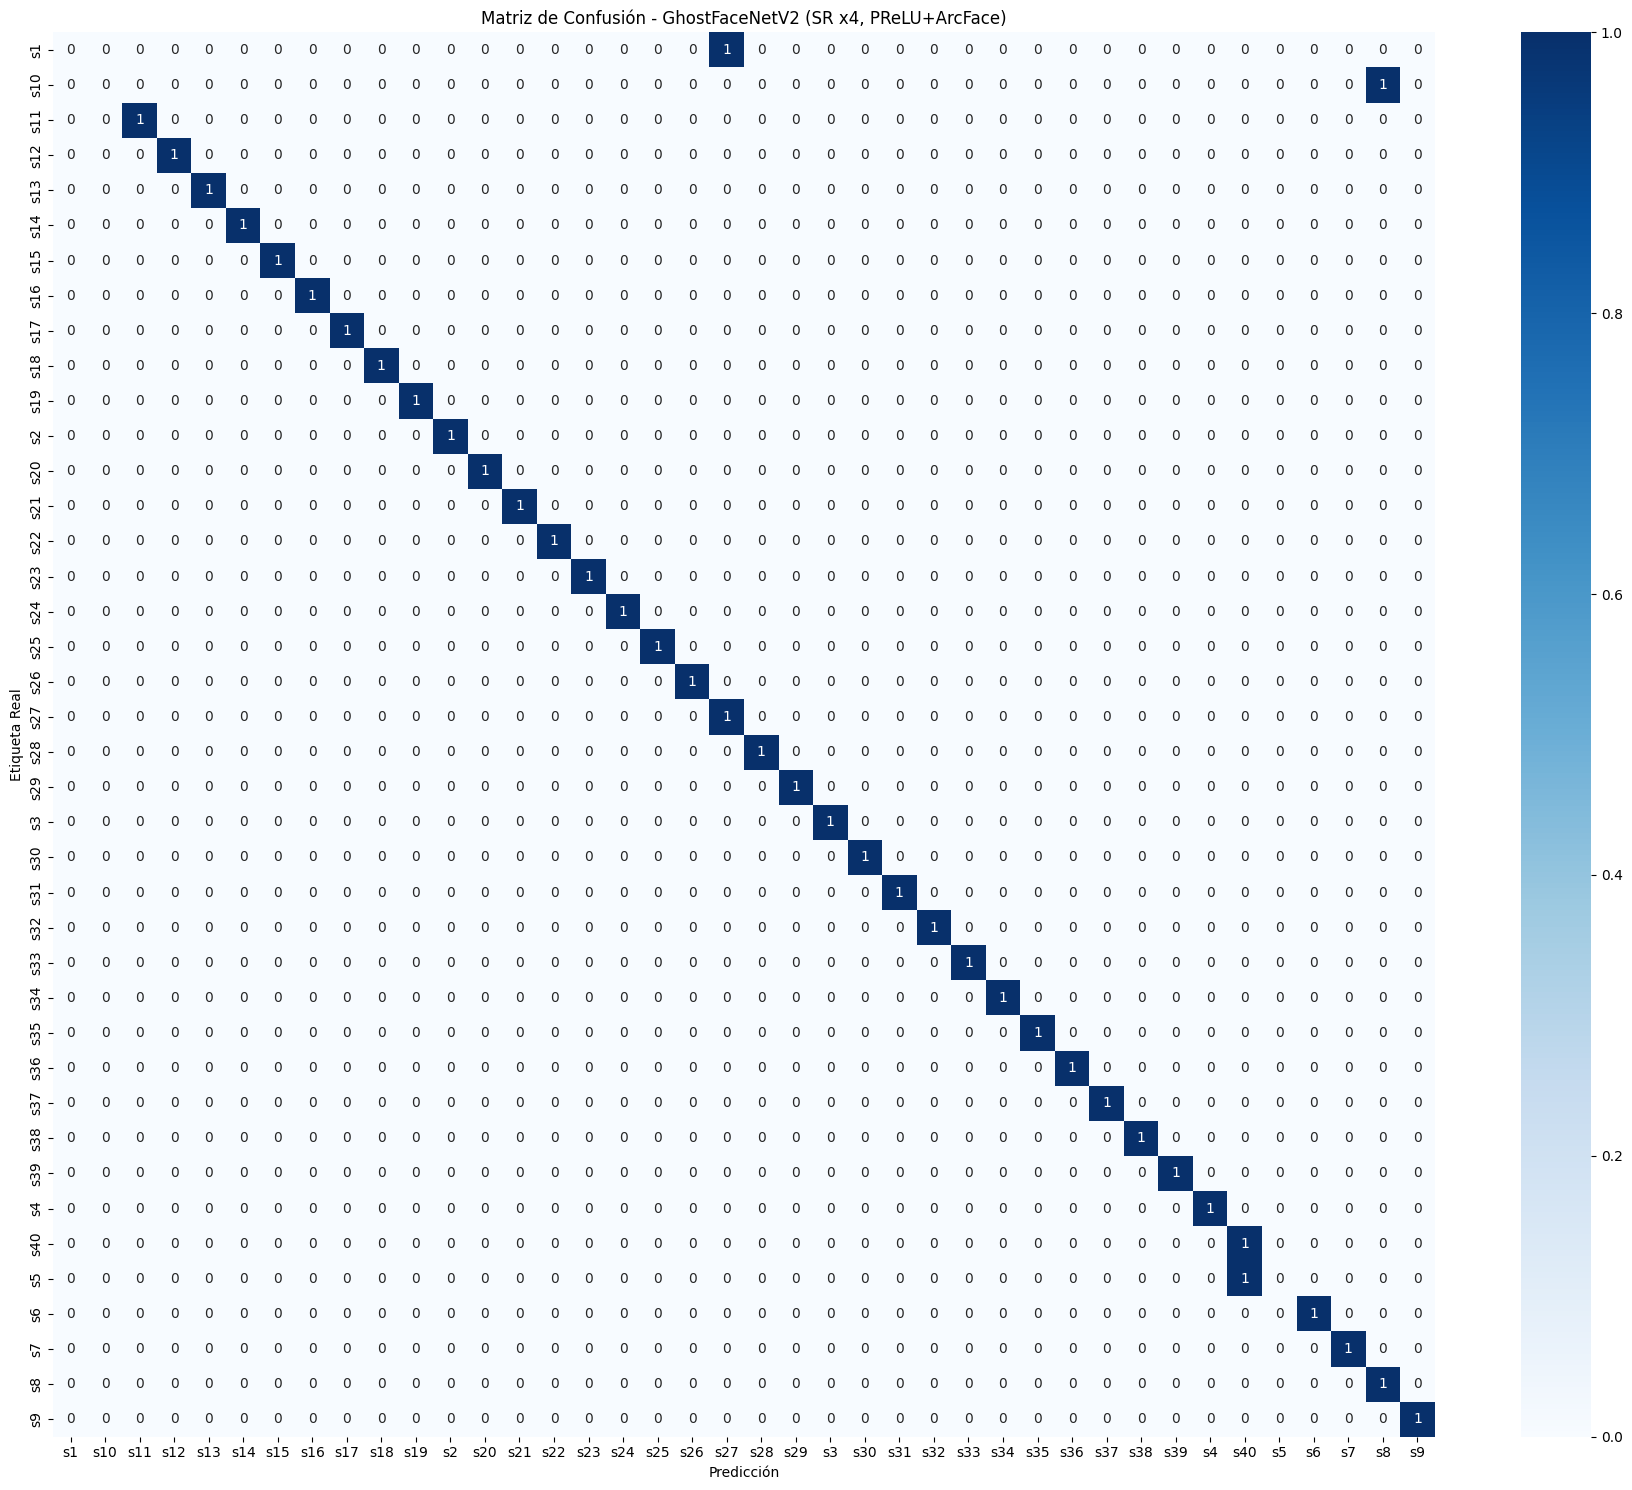

In [27]:
cm = confusion_matrix(all_labels, all_preds)
 
plt.figure(figsize=(18, 15))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=SR_x4_class_names,
            yticklabels=SR_x4_class_names)
plt.title("Matriz de Confusión - GhostFaceNetV2 (SR x4, PReLU+ArcFace)")
plt.xlabel("Predicción")
plt.ylabel("Etiqueta Real")
plt.tight_layout()
plt.show()

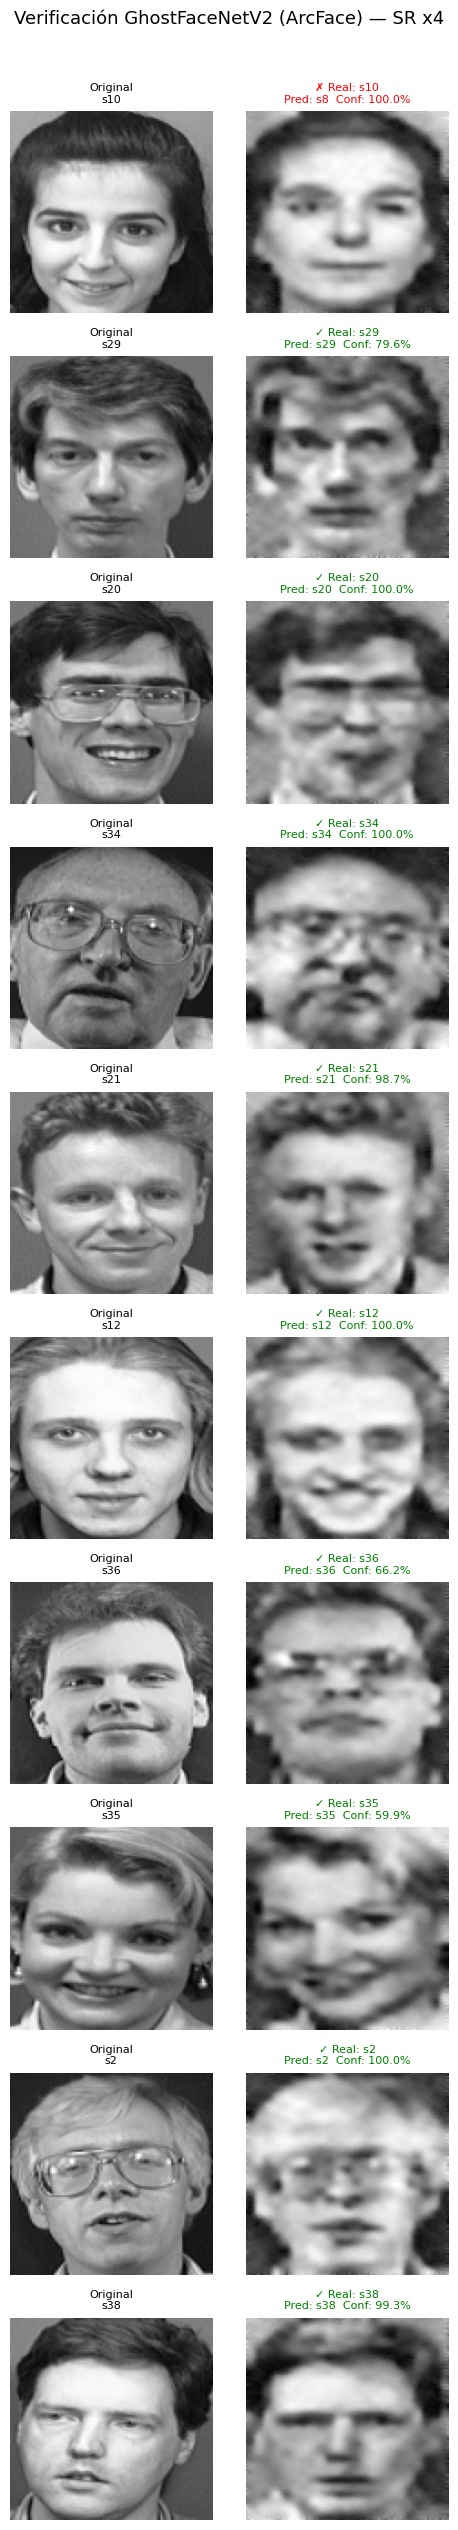


--- Resumen de verificación ---
Identificados correctamente : 37/40
Accuracy total              : 92.50%


In [28]:
def plot_verification(SR_x4_train_dataset, SR_x4_test_dataset, model, head, n=10):
    model.eval()
    head.eval()
    clean_transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((IMG_HEIGHT, IMG_WIDTH)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5]),
    ])

    # Referencia limpia desde CLAHE x2 (no ORL), para comparar como manzanas con manzanas
    train_dataset_clean = datasets.ImageFolder(TRAIN_PATH, transform=clean_transform)

    train_reference = {}
    for img, label in train_dataset_clean:
        if label not in train_reference:
            train_reference[label] = img

    # Seleccionar n sujetos aleatorios del test
    indices = np.random.choice(len(SR_x4_test_dataset), n, replace=False)

    fig, axes = plt.subplots(n, 2, figsize=(5, n * 2.5))
    fig.suptitle("Verificación GhostFaceNetV2 (ArcFace) — SR x4", fontsize=13, y=1.01)

    with torch.no_grad():
        for row, idx in enumerate(indices):
            img_test, label = SR_x4_test_dataset[idx]

            # Predicción con confianza (embedding -> cabeza ArcFace, sin margen en inferencia)
            emb    = extract_embedding(model, img_test.unsqueeze(0).to(DEVICE))
            logits = head(emb)
            probs  = torch.softmax(logits, dim=1)
            conf, pred = probs.max(1)
            pred    = pred.item()
            conf    = conf.item() * 100

            # Desnormalizar para visualizar
            def denorm(t):
                return (t.squeeze().cpu().numpy() * 0.5 + 0.5).clip(0, 1)

            img_train_show = denorm(train_reference[label])
            img_test_show  = denorm(img_test)

            correct = (pred == label)
            color   = 'green' if correct else 'red'
            symbol  = '✓' if correct else '✗'

            # ---- Columna izquierda: imagen de referencia (train) ----
            axes[row, 0].imshow(img_train_show, cmap='gray')
            axes[row, 0].set_title(f"Original\n{SR_x4_class_names[label]}", fontsize=8)
            axes[row, 0].axis('off')

            # ---- Columna derecha: imagen de test + resultado ----
            axes[row, 1].imshow(img_test_show, cmap='gray')
            axes[row, 1].set_title(
                f"{symbol} Real: {SR_x4_class_names[label]}\nPred: {SR_x4_class_names[pred]}  Conf: {conf:.1f}%",
                fontsize=8, color=color
            )
            axes[row, 1].axis('off')

    plt.tight_layout()
    plt.show()

    # Resumen numérico
    print("\n--- Resumen de verificación ---")
    correct_total = 0
    with torch.no_grad():
        for img_test, label in SR_x4_test_dataset:
            emb    = extract_embedding(model, img_test.unsqueeze(0).to(DEVICE))
            logits = head(emb)
            pred   = logits.argmax(1).item()
            if pred == label:
                correct_total += 1
    print(f"Identificados correctamente : {correct_total}/{len(SR_x4_test_dataset)}")
    print(f"Accuracy total              : {correct_total/len(SR_x4_test_dataset)*100:.2f}%")


plot_verification(SR_x4_train_dataset, SR_x4_test_dataset, model_arcface, head, n=10)

# Experimento 4: Ablation de la rama DFC (SR x4)

In [29]:
model_with_dfc = GhostFaceNetV2(num_classes=NUM_CLASSES, use_dfc=True)
model_no_dfc   = GhostFaceNetV2(num_classes=NUM_CLASSES, use_dfc=False)
 
n_params_with_dfc = sum(p.numel() for p in model_with_dfc.parameters())
n_params_no_dfc   = sum(p.numel() for p in model_no_dfc.parameters())
dfc_overhead      = n_params_with_dfc - n_params_no_dfc
 
print("=== Comparación de parámetros ===")
print(f"GhostFaceNetV2 (con DFC) : {n_params_with_dfc:,} parámetros")
print(f"GhostFaceNetV1 (sin DFC) : {n_params_no_dfc:,} parámetros")
print(f"Overhead de la rama DFC  : {dfc_overhead:,} parámetros "
      f"({100*dfc_overhead/n_params_no_dfc:.2f}% más que sin DFC)")
 
del model_with_dfc  # solo se usó para contar parámetros

=== Comparación de parámetros ===
GhostFaceNetV2 (con DFC) : 725,288 parámetros
GhostFaceNetV1 (sin DFC) : 697,448 parámetros
Overhead de la rama DFC  : 27,840 parámetros (3.99% más que sin DFC)


In [30]:
model_no_dfc = model_no_dfc.to(DEVICE)
 
orl_state   = torch.load("best_ghostfacenet_orl.pth", map_location=DEVICE)
model_state = model_no_dfc.state_dict()
compatible_state = {
    k: v for k, v in orl_state.items()
    if k in model_state and v.shape == model_state[k].shape
}
model_state.update(compatible_state)
model_no_dfc.load_state_dict(model_state)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.SGD(model_no_dfc.parameters(), lr=LEARNING_RATE,
                             momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
 
warmup_epochs = 5
def lr_lambda(epoch):
    if epoch < warmup_epochs:
        return (epoch + 1) / warmup_epochs
    return 1.0
 
warmup_scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)
cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS - warmup_epochs)

In [31]:
history_no_dfc = {
    "train_loss": [], "train_acc": [],
    "val_loss": [], "val_acc": [],
    "lr": [], "best_acc": 0.0, "best_epoch": 0
}
 
best_acc = 0.0
patience = 12
counter  = 0
 
for epoch in range(EPOCHS):
    model_no_dfc.train()
    running_loss, correct, total = 0.0, 0, 0
 
    for images, labels in SR_x4_train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
 
        optimizer.zero_grad()
        outputs = model_no_dfc(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
 
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
 
    train_loss = running_loss / total
    train_acc  = 100 * correct / total
 
    model_no_dfc.eval()
    running_loss, correct, total = 0.0, 0, 0
 
    with torch.no_grad():
        for images, labels in SR_x4_test_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model_no_dfc(images)
            loss = criterion(outputs, labels)
 
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
 
    val_loss = running_loss / total
    val_acc  = 100 * correct / total
 
    if epoch < warmup_epochs:
        warmup_scheduler.step()
    else:
        cosine_scheduler.step()
 
    current_lr = optimizer.param_groups[0]['lr']
 
    history_no_dfc["train_loss"].append(train_loss)
    history_no_dfc["train_acc"].append(train_acc)
    history_no_dfc["val_loss"].append(val_loss)
    history_no_dfc["val_acc"].append(val_acc)
    history_no_dfc["lr"].append(current_lr)
 
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | LR: {current_lr:.6f} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}%")
 
    if val_acc > best_acc:
        best_acc = val_acc
        history_no_dfc["best_acc"] = best_acc
        history_no_dfc["best_epoch"] = epoch + 1
        counter = 0
        torch.save(model_no_dfc.state_dict(), "best_ghostfacenet_noDFC_SR_x4_experimento4.pth")
    else:
        counter += 1
        if counter >= patience:
            print(f"\nEarly stopping en epoch {epoch+1} (sin mejora por {patience} epochs)")
            break
 
print(f"\nMejor Val Accuracy (sin DFC): {history_no_dfc['best_acc']:.2f}% (Epoch {history_no_dfc['best_epoch']})")

with open("history_ghostfacenet_SR_x4_experimento4.json", "w") as f:
    json.dump(history_no_dfc, f, indent=2)

Epoch 01/50 | LR: 0.004000 | Train Loss: 1.0858 Acc: 92.50% | Val Loss: 1.3802 Acc: 72.50%
Epoch 02/50 | LR: 0.006000 | Train Loss: 1.0255 Acc: 94.44% | Val Loss: 1.3511 Acc: 80.00%
Epoch 03/50 | LR: 0.008000 | Train Loss: 1.0047 Acc: 95.00% | Val Loss: 1.3440 Acc: 85.00%
Epoch 04/50 | LR: 0.010000 | Train Loss: 0.9909 Acc: 96.39% | Val Loss: 1.4256 Acc: 82.50%
Epoch 05/50 | LR: 0.010000 | Train Loss: 0.9815 Acc: 95.56% | Val Loss: 1.3291 Acc: 82.50%
Epoch 06/50 | LR: 0.009988 | Train Loss: 0.9719 Acc: 95.83% | Val Loss: 1.3813 Acc: 82.50%
Epoch 07/50 | LR: 0.009951 | Train Loss: 0.9784 Acc: 96.94% | Val Loss: 1.4081 Acc: 77.50%
Epoch 08/50 | LR: 0.009891 | Train Loss: 0.9741 Acc: 95.56% | Val Loss: 1.3527 Acc: 85.00%
Epoch 09/50 | LR: 0.009806 | Train Loss: 0.9464 Acc: 96.94% | Val Loss: 1.3154 Acc: 82.50%
Epoch 10/50 | LR: 0.009698 | Train Loss: 0.9270 Acc: 98.06% | Val Loss: 1.2714 Acc: 80.00%
Epoch 11/50 | LR: 0.009568 | Train Loss: 0.8982 Acc: 98.61% | Val Loss: 1.2436 Acc: 82.50%

In [32]:
model_no_dfc.load_state_dict(torch.load("best_ghostfacenet_noDFC_SR_x4_experimento4.pth", map_location=DEVICE))
model_no_dfc.eval()
 
all_preds, all_labels, all_confs = [], [], []
 
with torch.no_grad():
    for images, labels in SR_x4_test_loader:
        images = images.to(DEVICE)
        outputs = model_no_dfc(images)
        probs = F.softmax(outputs, dim=1)
        confs, preds = torch.max(probs, dim=1)
 
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_confs.extend(confs.cpu().numpy())
 
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_confs  = np.array(all_confs) * 100
 
final_acc_no_dfc = 100 * np.sum(all_preds == all_labels) / len(all_labels)
print(f"\n=== [SR x4] Experimento 4 — Ablation: sin DFC (CE) ===")
print(f"Accuracy final en Test: {final_acc_no_dfc:.2f}%")
print(f"Confianza promedio: {all_confs.mean():.2f}%")
print(f"Confianza mínima  : {all_confs.min():.2f}%")
print(f"Confianza máxima  : {all_confs.max():.2f}%")
print(f"Desviación estándar: {all_confs.std():.2f}%")
print("\n" + "="*60)
print("REPORTE DE CLASIFICACIÓN")
print("="*60)
print(classification_report(all_labels, all_preds, target_names=SR_x4_class_names, zero_division=0))


=== [SR x4] Experimento 4 — Ablation: sin DFC (CE) ===
Accuracy final en Test: 87.50%
Confianza promedio: 68.99%
Confianza mínima  : 22.73%
Confianza máxima  : 96.53%
Desviación estándar: 23.01%

REPORTE DE CLASIFICACIÓN
              precision    recall  f1-score   support

          s1       1.00      1.00      1.00         1
         s10       0.00      0.00      0.00         1
         s11       1.00      1.00      1.00         1
         s12       1.00      1.00      1.00         1
         s13       0.50      1.00      0.67         1
         s14       1.00      1.00      1.00         1
         s15       1.00      1.00      1.00         1
         s16       0.00      0.00      0.00         1
         s17       1.00      1.00      1.00         1
         s18       0.50      1.00      0.67         1
         s19       1.00      1.00      1.00         1
          s2       1.00      1.00      1.00         1
         s20       1.00      1.00      1.00         1
         s21       1.

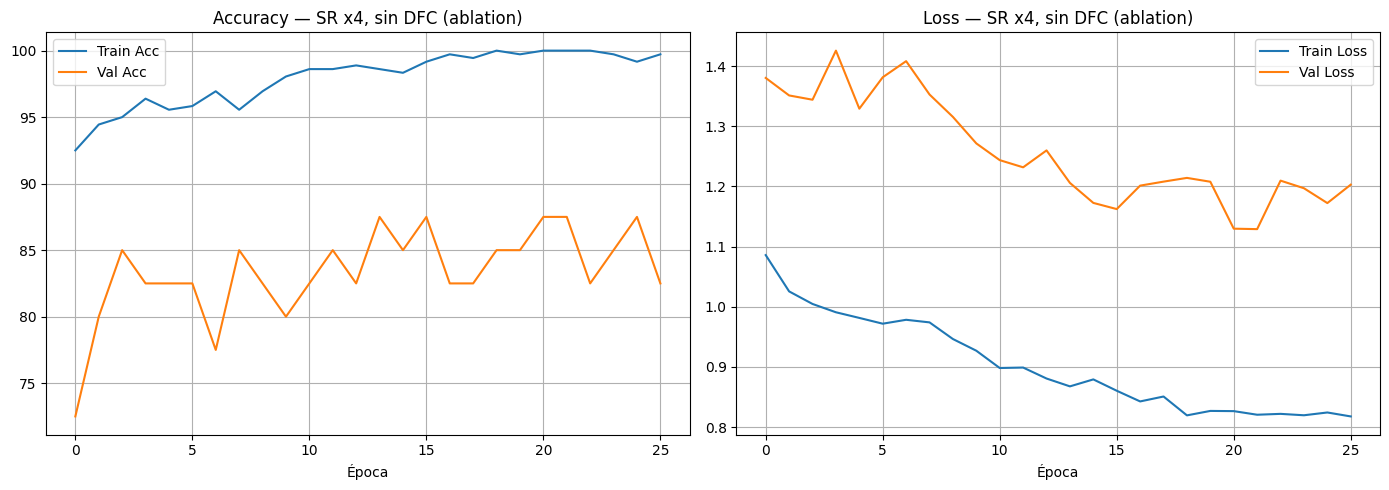

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
axes[0].plot(history_no_dfc['train_acc'], label='Train Acc')
axes[0].plot(history_no_dfc['val_acc'],   label='Val Acc')
axes[0].set_title('Accuracy — SR x4, sin DFC (ablation)')
axes[0].set_xlabel('Época')
axes[0].legend(); axes[0].grid(True)
 
axes[1].plot(history_no_dfc['train_loss'], label='Train Loss')
axes[1].plot(history_no_dfc['val_loss'],   label='Val Loss')
axes[1].set_title('Loss — SR x4, sin DFC (ablation)')
axes[1].set_xlabel('Época')
axes[1].legend(); axes[1].grid(True)
 
plt.tight_layout()
plt.show()

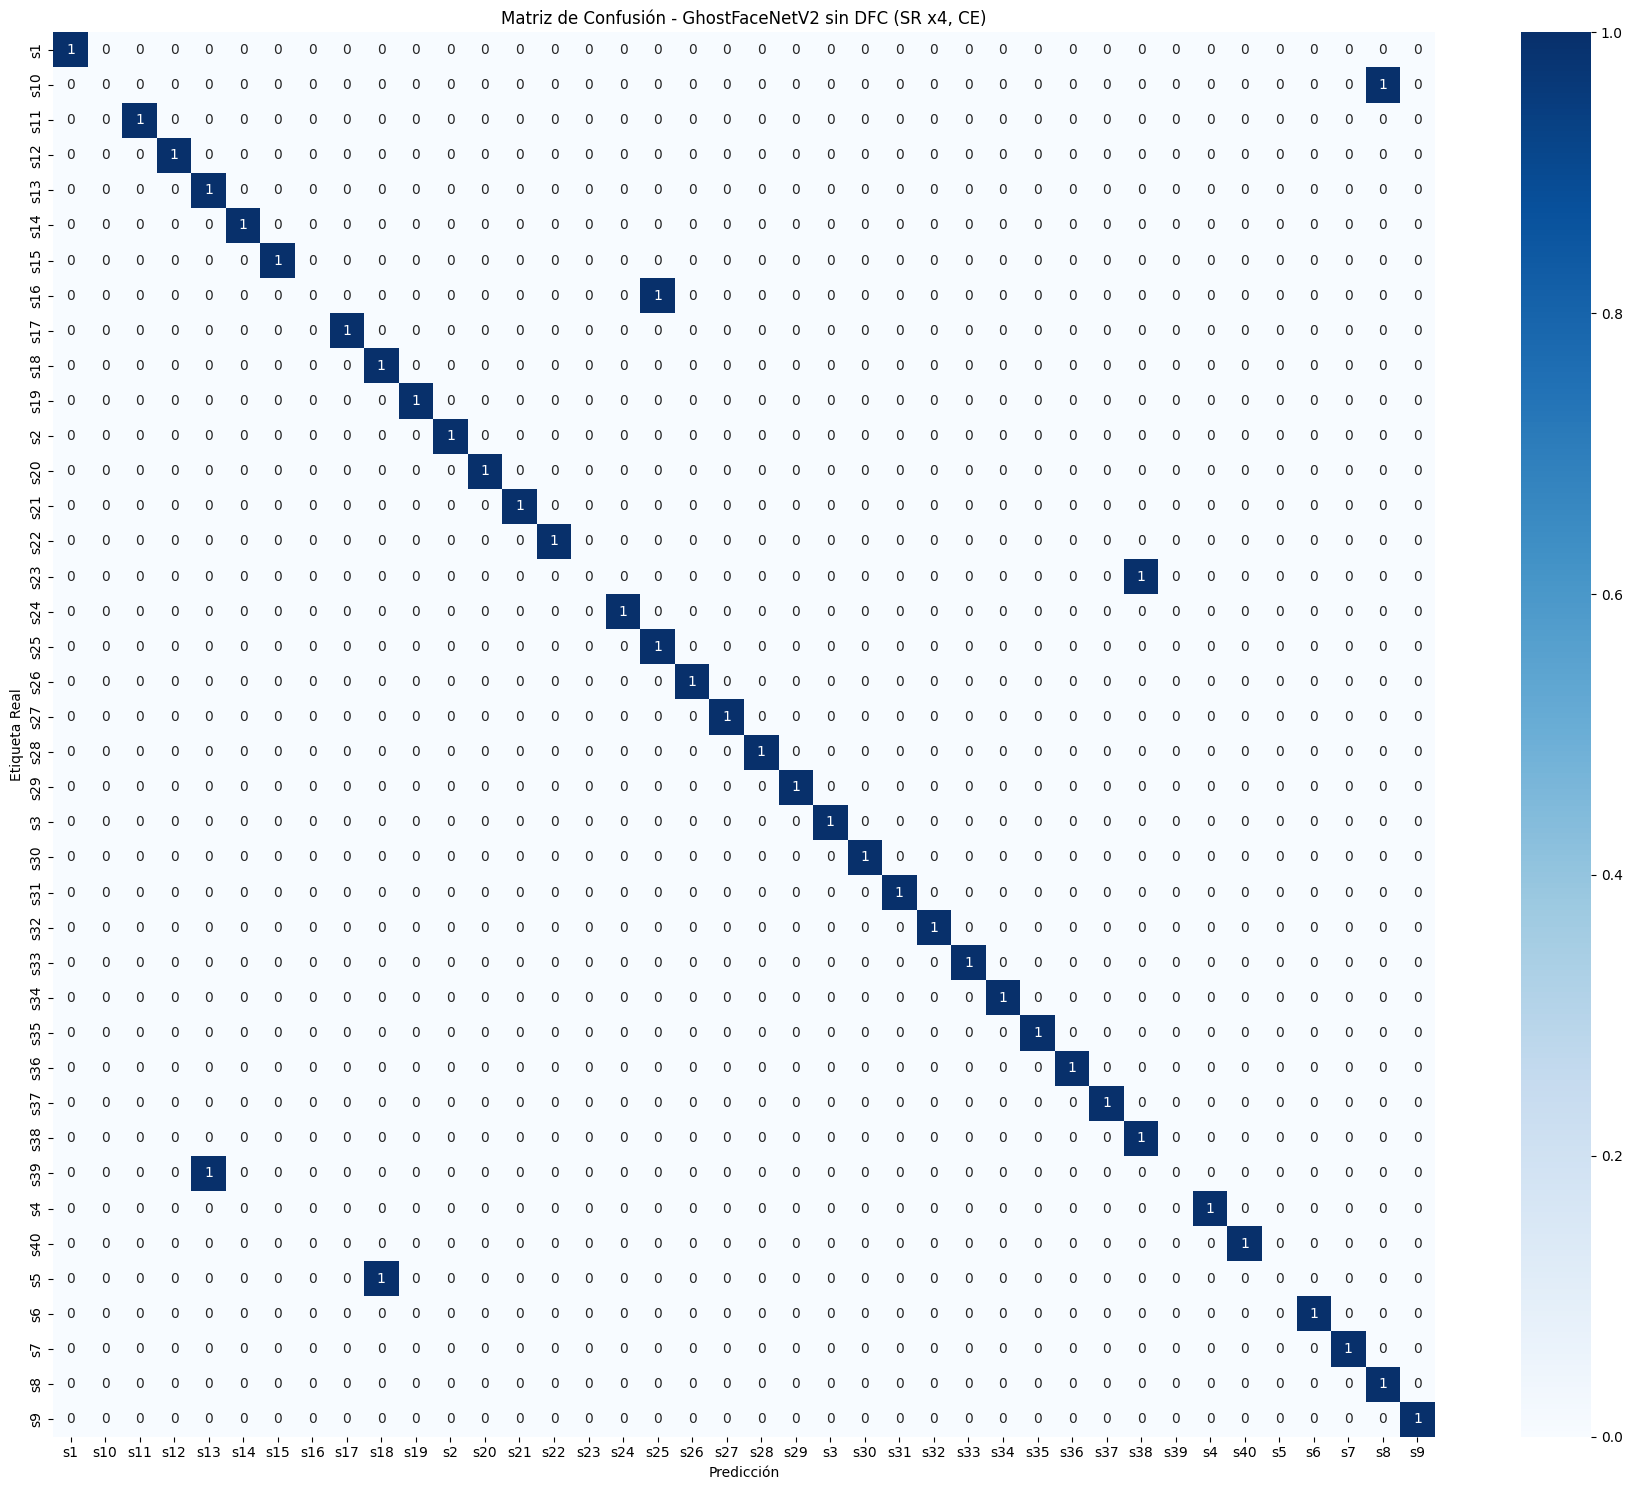

In [34]:
cm = confusion_matrix(all_labels, all_preds)
 
plt.figure(figsize=(18, 15))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=SR_x4_class_names,
            yticklabels=SR_x4_class_names)
plt.title("Matriz de Confusión - GhostFaceNetV2 sin DFC (SR x4, CE)")
plt.xlabel("Predicción")
plt.ylabel("Etiqueta Real")
plt.tight_layout()
plt.show()

In [35]:
acc_con_dfc = final_acc
 
print("\n" + "="*60)
print("RESUMEN ABLATION — Rama DFC (SR x4)")
print("="*60)
print(f"{'Variante':<25}{'Accuracy':>12}{'Parámetros':>18}")
print(f"{'Con DFC (Exp. 2)':<25}{(f'{acc_con_dfc:.2f}%' if acc_con_dfc is not None else 'pendiente'):>12}{n_params_with_dfc:>18,}")
print(f"{'Sin DFC (Exp. 4)':<25}{final_acc_no_dfc:>11.2f}%{n_params_no_dfc:>18,}")


RESUMEN ABLATION — Rama DFC (SR x4)
Variante                     Accuracy        Parámetros
Con DFC (Exp. 2)               87.50%           725,288
Sin DFC (Exp. 4)               87.50%           697,448


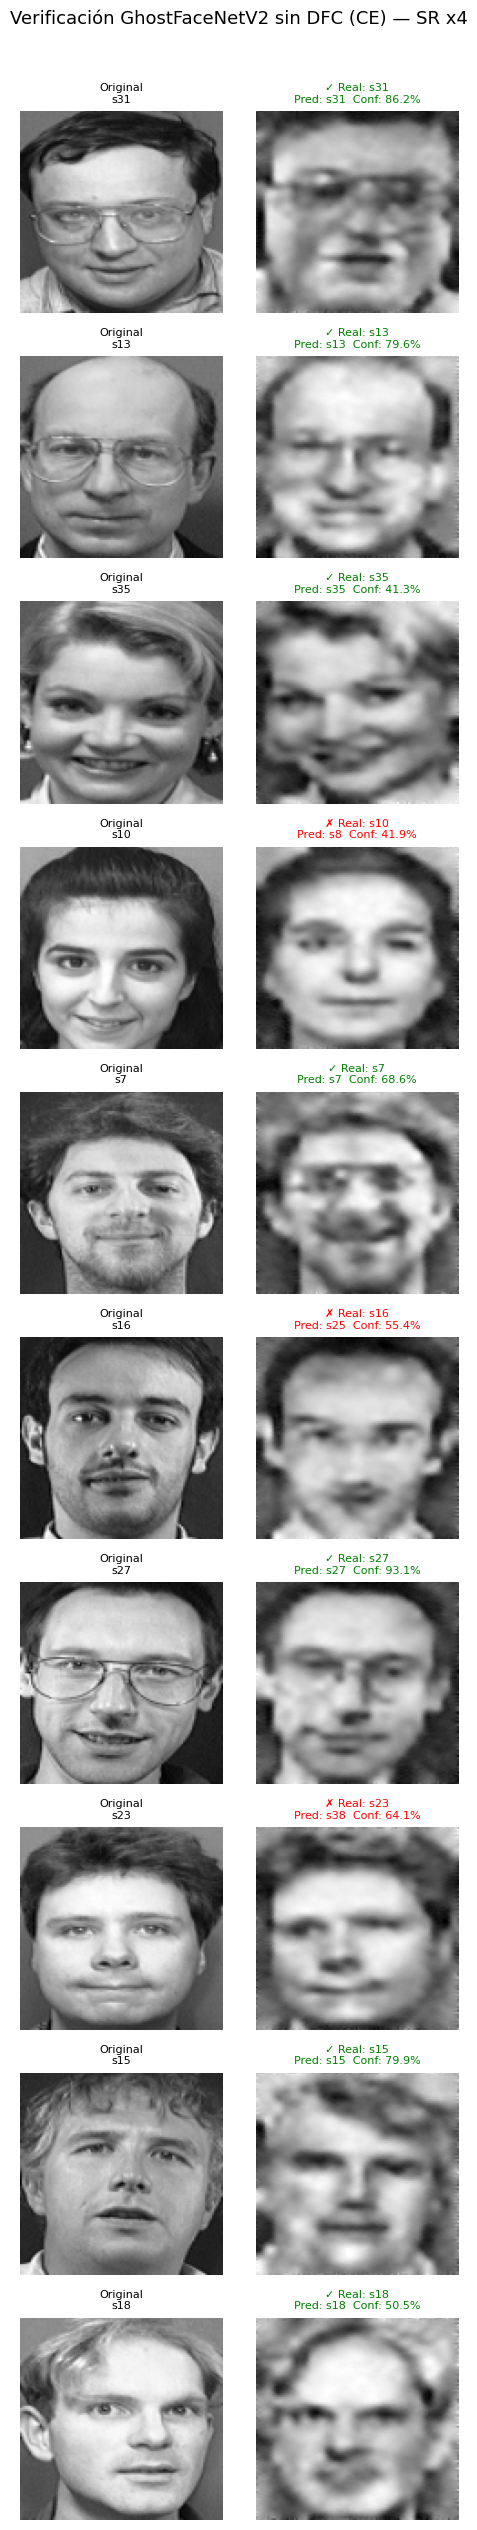


--- Resumen de verificación ---
Identificados correctamente : 35/40
Accuracy total              : 87.50%


In [36]:
def plot_verification_ce(train_dataset_path, test_dataset, class_names, model, n=10):
    model.eval()
    clean_transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((IMG_HEIGHT, IMG_WIDTH)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5]),
    ])

    train_dataset_clean = datasets.ImageFolder(train_dataset_path, transform=clean_transform)

    train_reference = {}
    for img, label in train_dataset_clean:
        if label not in train_reference:
            train_reference[label] = img

    indices = np.random.choice(len(test_dataset), n, replace=False)

    fig, axes = plt.subplots(n, 2, figsize=(5, n * 2.5))
    fig.suptitle("Verificación GhostFaceNetV2 sin DFC (CE) — SR x4", fontsize=13, y=1.01)

    with torch.no_grad():
        for row, idx in enumerate(indices):
            img_test, label = test_dataset[idx]

            # Predicción directa (classifier lineal, sin ArcFace)
            logits  = model(img_test.unsqueeze(0).to(DEVICE))
            probs   = torch.softmax(logits, dim=1)
            conf, pred = probs.max(1)
            pred    = pred.item()
            conf    = conf.item() * 100

            def denorm(t):
                return (t.squeeze().cpu().numpy() * 0.5 + 0.5).clip(0, 1)

            img_train_show = denorm(train_reference[label])
            img_test_show  = denorm(img_test)

            correct = (pred == label)
            color   = 'green' if correct else 'red'
            symbol  = '✓' if correct else '✗'

            axes[row, 0].imshow(img_train_show, cmap='gray')
            axes[row, 0].set_title(f"Original\n{class_names[label]}", fontsize=8)
            axes[row, 0].axis('off')

            axes[row, 1].imshow(img_test_show, cmap='gray')
            axes[row, 1].set_title(
                f"{symbol} Real: {class_names[label]}\nPred: {class_names[pred]}  Conf: {conf:.1f}%",
                fontsize=8, color=color
            )
            axes[row, 1].axis('off')

    plt.tight_layout()
    plt.show()

    print("\n--- Resumen de verificación ---")
    correct_total = 0
    with torch.no_grad():
        for img_test, label in test_dataset:
            logits = model(img_test.unsqueeze(0).to(DEVICE))
            pred   = logits.argmax(1).item()
            if pred == label:
                correct_total += 1
    print(f"Identificados correctamente : {correct_total}/{len(test_dataset)}")
    print(f"Accuracy total              : {correct_total/len(test_dataset)*100:.2f}%")


plot_verification_ce(TRAIN_PATH, SR_x4_test_dataset, SR_x4_class_names, model_no_dfc, n=10)